In [1]:
import torch
import numpy as np
import random

SEED = 134

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4080 SUPER


In [2]:
import torchvision
import os

# Local path relative to your notebook's working directory — no Drive/Colab dependency.
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

# Downloads from the official CIFAR-10 host (https://www.cs.toronto.edu/~kriz/cifar.html),
# torchvision verifies the checksum internally. Only runs once — if ./data/cifar-10-batches-py
# already exists with valid files, torchvision skips re-downloading on future runs.
_ = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,  download=True)
_ = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True)

print("Download complete.")
print("Contents:", os.listdir(os.path.join(DATA_DIR, "cifar-10-batches-py")))

Download complete.
Contents: ['data_batch_1', 'data_batch_4', 'batches.meta', 'data_batch_3', 'data_batch_2', 'test_batch', 'readme.html', 'data_batch_5']


In [4]:
import torchvision.transforms as transforms

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

print("Transforms defined.")

Transforms defined.


In [5]:
from torch.utils.data import random_split, Subset

DATA_DIR = "./data"

# We load the 50k training images TWICE, with different transform objects:
#   - train_set_aug   -> has random crop/flip active (used for the 45k training subset)
#   - train_set_plain -> no augmentation (used for the 5k validation subset)
# This is necessary because a validation set must be evaluated deterministically,
# but Subset() only lets us pick indices, not swap transforms per-index.
train_set_aug   = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=train_transform)
train_set_plain = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=eval_transform)
test_set        = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=eval_transform)

# Fixed, reproducible split: same SEED -> same 45000/5000 index assignment every run.
split_generator = torch.Generator().manual_seed(SEED)
train_idx_split, val_idx_split = random_split(range(len(train_set_aug)), [45000, 5000], generator=split_generator)

# Same indices, but pulled from the two differently-transformed dataset objects.
train_subset = Subset(train_set_aug,   train_idx_split.indices)
val_subset   = Subset(train_set_plain, val_idx_split.indices)

print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_set)}")

Train: 45000 | Val: 5000 | Test: 10000


In [6]:
from torch.utils.data import DataLoader

BATCH_SIZE = 128

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,     batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Sanity check: confirm shapes/label range are what we expect (3x32x32 images, labels 0-9)
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, Label range: {labels.min().item()}-{labels.max().item()}")

Batch shape: torch.Size([128, 3, 32, 32]), Label range: 0-9


In [7]:
#Cell 5 — Basic Residual Block

import torch.nn as nn

class BasicBlock(nn.Module):
    """
    The residual block used in ResNet18/34 (He et al., 2016).
    Two 3x3 convs with BatchNorm+ReLU, plus a shortcut connection.

    Core idea from the paper: instead of learning H(x) directly, this block
    learns F(x) = H(x) - x, and outputs F(x) + x. If input/output dimensions
    match, the shortcut is the identity; if they don't (stride>1 or channel
    change), the shortcut is a 1x1 conv projection.
    """
    expansion = 1  # BasicBlock doesn't expand channels internally (Bottleneck blocks do, not used here)

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut: identity if shapes match, else a 1x1 projection conv
        # (this is the "W_s * x" case from the ResNet paper's shortcut equation)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity   # <-- the residual addition: F(x) + x
        out = self.relu(out)
        return out

In [9]:
#Cell 6 — Generic ResNet (CIFAR-adapted stem)class ResNetCIFAR(nn.Module):
class ResNetCIFAR(nn.Module):
    """
    Generic ResNet for CIFAR-10 (32x32 images), built from BasicBlocks.

    IMPORTANT design choice (locked earlier): this uses the CIFAR-adapted stem
    (3x3 conv, stride 1, NO initial maxpool) instead of the ImageNet stem
    (7x7 conv stride 2 + maxpool). The ImageNet stem downsamples 224x224 -> 56x56
    before the first residual stage; applying that same aggressive downsampling
    to a 32x32 CIFAR image would shrink it to 8x8 almost immediately, discarding
    most spatial detail. This is standard practice in every CIFAR ResNet paper.

    num_blocks: list of 4 ints, e.g. [3,4,6,3] for ResNet34, [2,2,2,2] for ResNet18
    """
    def __init__(self, num_blocks, num_classes=10):
        super().__init__()
        self.in_channels = 64

        # Stem: single 3x3 conv, stride 1 -> output stays 32x32
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        # 4 stages, channel widths [64,128,256,512], matching the paper.
        # Stage 1 keeps spatial size (stride=1), stages 2-4 downsample by 2 each (stride=2).
        self.stage1 = self._make_stage(64,  num_blocks[0], stride=1)
        self.stage2 = self._make_stage(128, num_blocks[1], stride=2)
        self.stage3 = self._make_stage(256, num_blocks[2], stride=2)
        self.stage4 = self._make_stage(512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_stage(self, out_channels, num_blocks, stride):
        # First block in the stage may downsample (stride param); rest keep stride=1.
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, stride=s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.stem(x)
        out = self.stage1(out)
        out = self.stage2(out)
        out = self.stage3(out)
        out = self.stage4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

In [11]:
#Cell 7 — ResNet34 constructor + sanity check
def ResNet34(num_classes=10):
    # [3,4,6,3] blocks per stage -> matches He et al.'s ResNet34 exactly
    return ResNetCIFAR(num_blocks=[3, 4, 6, 3], num_classes=num_classes)

teacher = ResNet34(num_classes=10).to(device)

# Sanity check: forward pass with a dummy batch, confirm output shape is [batch, 10]
dummy_input = torch.randn(2, 3, 32, 32).to(device)
dummy_output = teacher(dummy_input)
print(f"Output shape: {dummy_output.shape}")  # expect torch.Size([2, 10])

total_params = sum(p.numel() for p in teacher.parameters())
print(f"Total parameters: {total_params:,}")

Output shape: torch.Size([2, 10])
Total parameters: 21,282,122


In [13]:
#Cell 8 — Loss, optimizer, schedulerimport torch.optim as optim
import torch.optim as optim
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(teacher.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)

# Step decay at 100/150 out of 200 epochs (same 50%/75% shape as the locked 100-epoch plan,
# scaled up since we're now running 200 epochs)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 150], gamma=0.1)

NUM_EPOCHS = 200


In [14]:
#Cell 9 — Train/validate helper functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


In [15]:
#Cell 10 — Training loop with best-checkpoint saving + history logging

import os
import time

CHECKPOINT_DIR = "./checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
TEACHER_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "teacher_resnet34_best.pth")

# History dict -> used later to plot loss/accuracy curves for the report
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(teacher, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(teacher, val_loader, criterion, device)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Save checkpoint only when validation accuracy improves -> "best" checkpoint deliverable
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": teacher.state_dict(),
            "val_acc": val_acc,
        }, TEACHER_CKPT_PATH)

    elapsed = time.time() - start_time
    print(f"Epoch [{epoch}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"Best Val Acc: {best_val_acc:.2f}% | Time: {elapsed:.1f}s")

print(f"\nTraining complete. Best validation accuracy: {best_val_acc:.2f}%")
print(f"Best checkpoint saved to: {TEACHER_CKPT_PATH}")

Epoch [1/200] Train Loss: 2.1532 | Train Acc: 23.28% | Val Loss: 1.8136 | Val Acc: 34.02% | Best Val Acc: 34.02% | Time: 16.3s
Epoch [2/200] Train Loss: 1.6620 | Train Acc: 37.76% | Val Loss: 1.4957 | Val Acc: 44.68% | Best Val Acc: 44.68% | Time: 14.7s
Epoch [3/200] Train Loss: 1.4402 | Train Acc: 46.79% | Val Loss: 1.3516 | Val Acc: 51.58% | Best Val Acc: 51.58% | Time: 14.9s
Epoch [4/200] Train Loss: 1.2398 | Train Acc: 54.78% | Val Loss: 1.2538 | Val Acc: 56.04% | Best Val Acc: 56.04% | Time: 14.8s
Epoch [5/200] Train Loss: 1.0688 | Train Acc: 61.72% | Val Loss: 1.0747 | Val Acc: 60.74% | Best Val Acc: 60.74% | Time: 14.9s
Epoch [6/200] Train Loss: 0.9340 | Train Acc: 66.73% | Val Loss: 0.9782 | Val Acc: 66.22% | Best Val Acc: 66.22% | Time: 14.9s
Epoch [7/200] Train Loss: 0.8288 | Train Acc: 70.43% | Val Loss: 0.8015 | Val Acc: 72.42% | Best Val Acc: 72.42% | Time: 14.4s
Epoch [8/200] Train Loss: 0.7139 | Train Acc: 74.91% | Val Loss: 0.7215 | Val Acc: 75.44% | Best Val Acc: 75.44

Epoch [66/200] Train Loss: 0.1079 | Train Acc: 96.23% | Val Loss: 0.3369 | Val Acc: 90.16% | Best Val Acc: 90.50% | Time: 14.2s
Epoch [67/200] Train Loss: 0.0980 | Train Acc: 96.53% | Val Loss: 0.3620 | Val Acc: 90.02% | Best Val Acc: 90.50% | Time: 14.2s
Epoch [68/200] Train Loss: 0.1006 | Train Acc: 96.56% | Val Loss: 0.3822 | Val Acc: 88.92% | Best Val Acc: 90.50% | Time: 14.3s
Epoch [69/200] Train Loss: 0.0967 | Train Acc: 96.68% | Val Loss: 0.3858 | Val Acc: 89.72% | Best Val Acc: 90.50% | Time: 13.9s
Epoch [70/200] Train Loss: 0.0967 | Train Acc: 96.58% | Val Loss: 0.3394 | Val Acc: 90.26% | Best Val Acc: 90.50% | Time: 14.0s
Epoch [71/200] Train Loss: 0.0951 | Train Acc: 96.69% | Val Loss: 0.4015 | Val Acc: 88.78% | Best Val Acc: 90.50% | Time: 14.1s
Epoch [72/200] Train Loss: 0.0998 | Train Acc: 96.51% | Val Loss: 0.3350 | Val Acc: 90.90% | Best Val Acc: 90.90% | Time: 14.6s
Epoch [73/200] Train Loss: 0.1028 | Train Acc: 96.39% | Val Loss: 0.4184 | Val Acc: 88.64% | Best Val Ac

Epoch [130/200] Train Loss: 0.0014 | Train Acc: 99.98% | Val Loss: 0.2448 | Val Acc: 94.68% | Best Val Acc: 94.80% | Time: 14.2s
Epoch [131/200] Train Loss: 0.0012 | Train Acc: 99.98% | Val Loss: 0.2437 | Val Acc: 94.60% | Best Val Acc: 94.80% | Time: 14.2s
Epoch [132/200] Train Loss: 0.0017 | Train Acc: 99.96% | Val Loss: 0.2527 | Val Acc: 94.70% | Best Val Acc: 94.80% | Time: 14.3s
Epoch [133/200] Train Loss: 0.0010 | Train Acc: 99.98% | Val Loss: 0.2504 | Val Acc: 94.76% | Best Val Acc: 94.80% | Time: 14.3s
Epoch [134/200] Train Loss: 0.0012 | Train Acc: 99.98% | Val Loss: 0.2547 | Val Acc: 94.70% | Best Val Acc: 94.80% | Time: 14.3s
Epoch [135/200] Train Loss: 0.0011 | Train Acc: 99.98% | Val Loss: 0.2521 | Val Acc: 94.72% | Best Val Acc: 94.80% | Time: 13.9s
Epoch [136/200] Train Loss: 0.0010 | Train Acc: 99.98% | Val Loss: 0.2570 | Val Acc: 94.64% | Best Val Acc: 94.80% | Time: 14.2s
Epoch [137/200] Train Loss: 0.0010 | Train Acc: 99.98% | Val Loss: 0.2535 | Val Acc: 94.76% | Bes

Epoch [194/200] Train Loss: 0.0006 | Train Acc: 100.00% | Val Loss: 0.2492 | Val Acc: 94.78% | Best Val Acc: 95.00% | Time: 14.4s
Epoch [195/200] Train Loss: 0.0006 | Train Acc: 100.00% | Val Loss: 0.2536 | Val Acc: 94.88% | Best Val Acc: 95.00% | Time: 14.5s
Epoch [196/200] Train Loss: 0.0006 | Train Acc: 99.99% | Val Loss: 0.2517 | Val Acc: 94.80% | Best Val Acc: 95.00% | Time: 14.8s
Epoch [197/200] Train Loss: 0.0006 | Train Acc: 100.00% | Val Loss: 0.2544 | Val Acc: 94.68% | Best Val Acc: 95.00% | Time: 14.8s
Epoch [198/200] Train Loss: 0.0007 | Train Acc: 99.99% | Val Loss: 0.2510 | Val Acc: 94.78% | Best Val Acc: 95.00% | Time: 15.2s
Epoch [199/200] Train Loss: 0.0006 | Train Acc: 100.00% | Val Loss: 0.2530 | Val Acc: 94.68% | Best Val Acc: 95.00% | Time: 14.7s
Epoch [200/200] Train Loss: 0.0005 | Train Acc: 99.99% | Val Loss: 0.2543 | Val Acc: 94.70% | Best Val Acc: 95.00% | Time: 15.0s

Training complete. Best validation accuracy: 95.00%
Best checkpoint saved to: ./checkpoints/

In [20]:
#Cell 11 — Save training history (needed later for report curves)
import json

HISTORY_PATH = os.path.join(CHECKPOINT_DIR, "teacher_history.json")
with open(HISTORY_PATH, "w") as f:
    json.dump(history, f)

print(f"History saved to: {HISTORY_PATH}")

History saved to: ./checkpoints/teacher_history.json


In [17]:
#Cell 12 — Reload the best checkpoint (not the last-epoch weights)
# IMPORTANT: after training finishes, `teacher`'s in-memory weights are from the
# LAST epoch, not necessarily the BEST one (early stopping-by-selection happens at
# save-time, not automatically in memory). Reload the saved best checkpoint before
# computing any final metrics, so what you report is actually the best model.

checkpoint = torch.load(TEACHER_CKPT_PATH, map_location=device)
teacher.load_state_dict(checkpoint["model_state_dict"])
teacher.to(device)

print(f"Loaded best checkpoint from epoch {checkpoint['epoch']}, "
      f"val_acc={checkpoint['val_acc']:.2f}%")

Loaded best checkpoint from epoch 177, val_acc=95.00%


In [18]:
#Cell 13 — Final test-set evaluation (touching test set only now, at the very end)
# This is the FIRST and ONLY time the test set is used for the teacher —
# consistent with the held-out protocol we locked earlier.
test_loss, test_acc = evaluate(teacher, test_loader, criterion, device)
print(f"Teacher FINAL TEST — Loss: {test_loss:.4f} | Accuracy: {test_acc:.2f}%")

Teacher FINAL TEST — Loss: 0.2726 | Accuracy: 94.39%


In [19]:
#Cell 14 — Reconstruct LR history (deterministic from the schedule, since we didn't log it live)
# We didn't log LR per epoch during training, but MultiStepLR is fully deterministic
# given (initial_lr, milestones, gamma) — so we can reconstruct the exact per-epoch
# LR history after the fact, rather than needing to re-run training.

initial_lr = 0.1
milestones = [100, 150]
gamma = 0.1

lr_history = []
current_lr = initial_lr
for epoch in range(1, NUM_EPOCHS + 1):
    if epoch in milestones:
        current_lr *= gamma
    lr_history.append(current_lr)

history["lr"] = lr_history
print(f"LR history reconstructed: starts at {lr_history[0]}, "
      f"drops at epoch {milestones[0]} -> {lr_history[milestones[0]]}, "
      f"drops at epoch {milestones[1]} -> {lr_history[milestones[1]]}")

LR history reconstructed: starts at 0.1, drops at epoch 100 -> 0.010000000000000002, drops at epoch 150 -> 0.0010000000000000002


In [21]:
#Cell 15 — Model parameter/size info
total_params = sum(p.numel() for p in teacher.parameters())
trainable_params = sum(p.numel() for p in teacher.parameters() if p.requires_grad)

# FP32 = 4 bytes per parameter. This becomes your reference point later for
# computing the ternary student's compression ratio.
model_size_mb = total_params * 4 / (1024 ** 2)

param_info = {
    "total_params": total_params,
    "trainable_params": trainable_params,
    "model_size_mb_fp32": round(model_size_mb, 2)
}

print(param_info)

{'total_params': 21282122, 'trainable_params': 21282122, 'model_size_mb_fp32': 81.18}


In [22]:
#Cell 16 — Save one consolidated results file (everything in one place for the report)
final_results = {
    "best_epoch": checkpoint["epoch"],
    "best_val_acc": checkpoint["val_acc"],
    "test_loss": test_loss,
    "test_acc": test_acc,
    "param_info": param_info,
    "history": history,   # train_loss, train_acc, val_loss, val_acc, lr — all per-epoch lists
}

RESULTS_PATH = os.path.join(CHECKPOINT_DIR, "teacher_final_results.json")
with open(RESULTS_PATH, "w") as f:
    json.dump(final_results, f, indent=2)

print(f"Saved consolidated teacher results to: {RESULTS_PATH}")

Saved consolidated teacher results to: ./checkpoints/teacher_final_results.json


In [23]:
#Cell 17 — Model, loss, optimizer, scheduler (ResNet18, same recipe as teacher)
baseline = ResNet18 = ResNetCIFAR(num_blocks=[2, 2, 2, 2], num_classes=10).to(device)

total_params_baseline = sum(p.numel() for p in baseline.parameters())
print(f"Baseline ResNet18 params: {total_params_baseline:,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(baseline.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 150], gamma=0.1)

NUM_EPOCHS = 200
BASELINE_CKPT_PATH = os.path.join(CHECKPOINT_DIR, "baseline_resnet18_best.pth")

Baseline ResNet18 params: 11,173,962


In [24]:
#Cell 18 — Training loop (identical structure to teacher's Cell 10)
history_baseline = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc_baseline = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(baseline, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(baseline, val_loader, criterion, device)
    scheduler.step()

    history_baseline["train_loss"].append(train_loss)
    history_baseline["train_acc"].append(train_acc)
    history_baseline["val_loss"].append(val_loss)
    history_baseline["val_acc"].append(val_acc)

    if val_acc > best_val_acc_baseline:
        best_val_acc_baseline = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": baseline.state_dict(),
            "val_acc": val_acc,
        }, BASELINE_CKPT_PATH)

    elapsed = time.time() - start_time
    print(f"Epoch [{epoch}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"Best Val Acc: {best_val_acc_baseline:.2f}% | Time: {elapsed:.1f}s")

print(f"\nBaseline training complete. Best val accuracy: {best_val_acc_baseline:.2f}%")

Epoch [1/200] Train Loss: 2.0866 | Train Acc: 27.52% | Val Loss: 1.6555 | Val Acc: 38.20% | Best Val Acc: 38.20% | Time: 8.2s
Epoch [2/200] Train Loss: 1.5587 | Train Acc: 42.44% | Val Loss: 1.5169 | Val Acc: 45.88% | Best Val Acc: 45.88% | Time: 8.4s
Epoch [3/200] Train Loss: 1.3321 | Train Acc: 51.45% | Val Loss: 1.6517 | Val Acc: 46.78% | Best Val Acc: 46.78% | Time: 8.5s
Epoch [4/200] Train Loss: 1.1325 | Train Acc: 59.51% | Val Loss: 1.1899 | Val Acc: 58.82% | Best Val Acc: 58.82% | Time: 8.0s
Epoch [5/200] Train Loss: 0.9679 | Train Acc: 65.74% | Val Loss: 0.9156 | Val Acc: 67.08% | Best Val Acc: 67.08% | Time: 8.3s
Epoch [6/200] Train Loss: 0.8572 | Train Acc: 69.62% | Val Loss: 0.8708 | Val Acc: 68.96% | Best Val Acc: 68.96% | Time: 7.9s
Epoch [7/200] Train Loss: 0.7583 | Train Acc: 73.20% | Val Loss: 0.7956 | Val Acc: 73.06% | Best Val Acc: 73.06% | Time: 8.1s
Epoch [8/200] Train Loss: 0.6624 | Train Acc: 76.81% | Val Loss: 0.7321 | Val Acc: 74.74% | Best Val Acc: 74.74% | Tim

Epoch [66/200] Train Loss: 0.1059 | Train Acc: 96.34% | Val Loss: 0.3699 | Val Acc: 90.00% | Best Val Acc: 90.58% | Time: 7.5s
Epoch [67/200] Train Loss: 0.1100 | Train Acc: 96.11% | Val Loss: 0.3778 | Val Acc: 89.92% | Best Val Acc: 90.58% | Time: 8.0s
Epoch [68/200] Train Loss: 0.1090 | Train Acc: 96.16% | Val Loss: 0.3831 | Val Acc: 89.34% | Best Val Acc: 90.58% | Time: 7.7s
Epoch [69/200] Train Loss: 0.1038 | Train Acc: 96.35% | Val Loss: 0.3966 | Val Acc: 89.36% | Best Val Acc: 90.58% | Time: 8.2s
Epoch [70/200] Train Loss: 0.1053 | Train Acc: 96.30% | Val Loss: 0.3414 | Val Acc: 90.42% | Best Val Acc: 90.58% | Time: 7.8s
Epoch [71/200] Train Loss: 0.1026 | Train Acc: 96.45% | Val Loss: 0.4420 | Val Acc: 87.86% | Best Val Acc: 90.58% | Time: 7.8s
Epoch [72/200] Train Loss: 0.1028 | Train Acc: 96.47% | Val Loss: 0.3463 | Val Acc: 90.42% | Best Val Acc: 90.58% | Time: 7.8s
Epoch [73/200] Train Loss: 0.0990 | Train Acc: 96.56% | Val Loss: 0.3453 | Val Acc: 89.96% | Best Val Acc: 90.5

Epoch [131/200] Train Loss: 0.0023 | Train Acc: 99.97% | Val Loss: 0.2506 | Val Acc: 94.16% | Best Val Acc: 94.40% | Time: 8.3s
Epoch [132/200] Train Loss: 0.0020 | Train Acc: 99.98% | Val Loss: 0.2500 | Val Acc: 94.30% | Best Val Acc: 94.40% | Time: 8.0s
Epoch [133/200] Train Loss: 0.0021 | Train Acc: 99.98% | Val Loss: 0.2483 | Val Acc: 94.24% | Best Val Acc: 94.40% | Time: 8.2s
Epoch [134/200] Train Loss: 0.0021 | Train Acc: 99.98% | Val Loss: 0.2455 | Val Acc: 94.16% | Best Val Acc: 94.40% | Time: 8.3s
Epoch [135/200] Train Loss: 0.0019 | Train Acc: 99.98% | Val Loss: 0.2435 | Val Acc: 94.22% | Best Val Acc: 94.40% | Time: 8.3s
Epoch [136/200] Train Loss: 0.0021 | Train Acc: 99.97% | Val Loss: 0.2475 | Val Acc: 94.26% | Best Val Acc: 94.40% | Time: 8.2s
Epoch [137/200] Train Loss: 0.0021 | Train Acc: 99.98% | Val Loss: 0.2454 | Val Acc: 94.42% | Best Val Acc: 94.42% | Time: 8.4s
Epoch [138/200] Train Loss: 0.0017 | Train Acc: 99.99% | Val Loss: 0.2450 | Val Acc: 94.20% | Best Val A

Epoch [195/200] Train Loss: 0.0013 | Train Acc: 100.00% | Val Loss: 0.2447 | Val Acc: 94.30% | Best Val Acc: 94.48% | Time: 8.2s
Epoch [196/200] Train Loss: 0.0013 | Train Acc: 99.99% | Val Loss: 0.2444 | Val Acc: 94.34% | Best Val Acc: 94.48% | Time: 8.1s
Epoch [197/200] Train Loss: 0.0014 | Train Acc: 99.98% | Val Loss: 0.2424 | Val Acc: 94.40% | Best Val Acc: 94.48% | Time: 8.2s
Epoch [198/200] Train Loss: 0.0012 | Train Acc: 100.00% | Val Loss: 0.2454 | Val Acc: 94.32% | Best Val Acc: 94.48% | Time: 8.2s
Epoch [199/200] Train Loss: 0.0013 | Train Acc: 99.99% | Val Loss: 0.2441 | Val Acc: 94.28% | Best Val Acc: 94.48% | Time: 8.2s
Epoch [200/200] Train Loss: 0.0012 | Train Acc: 100.00% | Val Loss: 0.2433 | Val Acc: 94.26% | Best Val Acc: 94.48% | Time: 7.7s

Baseline training complete. Best val accuracy: 94.48%


In [25]:
#Cell 19 — Reload best checkpoint, test eval, param info, LR history, consolidated save (same pattern as teacher's Cells 12–16)
# Reload BEST (not last-epoch) weights before final evaluation
checkpoint = torch.load(BASELINE_CKPT_PATH, map_location=device)
baseline.load_state_dict(checkpoint["model_state_dict"])
baseline.to(device)
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']}, val_acc={checkpoint['val_acc']:.2f}%")

# Final test evaluation — first and only touch of the test set for this model
test_loss_baseline, test_acc_baseline = evaluate(baseline, test_loader, criterion, device)
print(f"Baseline FINAL TEST — Loss: {test_loss_baseline:.4f} | Accuracy: {test_acc_baseline:.2f}%")

# Reconstruct LR history (same schedule as teacher, deterministic)
lr_history = []
current_lr = 0.1
for epoch in range(1, NUM_EPOCHS + 1):
    if epoch in [100, 150]:
        current_lr *= 0.1
    lr_history.append(current_lr)
history_baseline["lr"] = lr_history

# Param/size info
trainable_params_baseline = sum(p.numel() for p in baseline.parameters() if p.requires_grad)
model_size_mb_baseline = total_params_baseline * 4 / (1024 ** 2)
param_info_baseline = {
    "total_params": total_params_baseline,
    "trainable_params": trainable_params_baseline,
    "model_size_mb_fp32": round(model_size_mb_baseline, 2)
}
print(param_info_baseline)

# Consolidated results file — same structure as teacher_final_results.json
final_results_baseline = {
    "best_epoch": checkpoint["epoch"],
    "best_val_acc": checkpoint["val_acc"],
    "test_loss": test_loss_baseline,
    "test_acc": test_acc_baseline,
    "param_info": param_info_baseline,
    "history": history_baseline,
}
BASELINE_RESULTS_PATH = os.path.join(CHECKPOINT_DIR, "baseline_final_results.json")
with open(BASELINE_RESULTS_PATH, "w") as f:
    json.dump(final_results_baseline, f, indent=2)
print(f"Saved: {BASELINE_RESULTS_PATH}")

Loaded best checkpoint from epoch 155, val_acc=94.48%
Baseline FINAL TEST — Loss: 0.2582 | Accuracy: 94.13%
{'total_params': 11173962, 'trainable_params': 11173962, 'model_size_mb_fp32': 42.63}
Saved: ./checkpoints/baseline_final_results.json


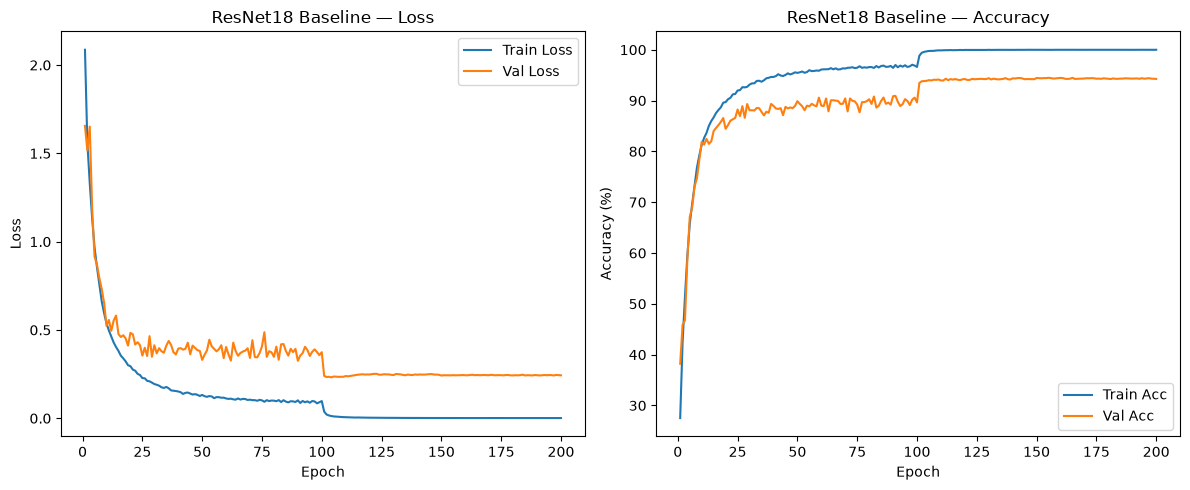

Saved plot to: ./checkpoints/baseline_training_curves.png


In [26]:
#Cell 20 — Plot + save training curves as PNG (new — also reusable for the teacher's saved history)
import matplotlib.pyplot as plt

def plot_and_save_curves(history, title_prefix, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title_prefix} — Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"{title_prefix} — Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved plot to: {save_path}")

plot_and_save_curves(
    history_baseline,
    title_prefix="ResNet18 Baseline",
    save_path=os.path.join(CHECKPOINT_DIR, "baseline_training_curves.png")
)


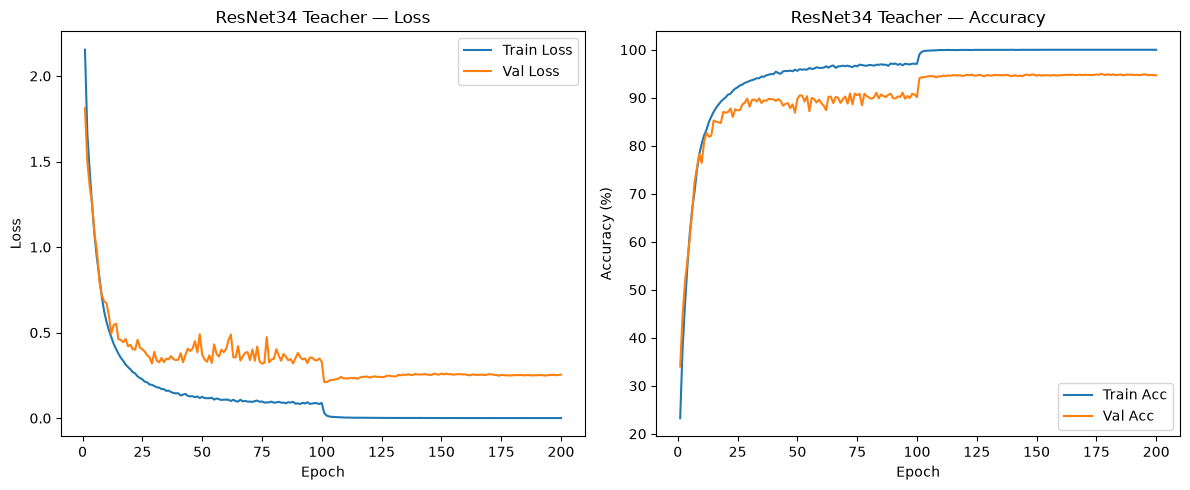

Saved plot to: ./checkpoints/teacher_training_curves.png


In [27]:
#cell 20.1 : teacher's plot:
with open(os.path.join(CHECKPOINT_DIR, "teacher_history.json")) as f:
    teacher_history = json.load(f)

plot_and_save_curves(
    teacher_history,
    title_prefix="ResNet34 Teacher",
    save_path=os.path.join(CHECKPOINT_DIR, "teacher_training_curves.png")
)

In [28]:
#Cell 21 — Clipped-STE ternarization as a custom autograd Function
import torch.nn.functional as F

class TernarizeSTE(torch.autograd.Function):
    """
    Implements TWN ternarization (per-layer Delta/alpha) in the forward pass,
    and CLIPPED Straight-Through Estimator in the backward pass.

    Forward:  W (latent FP32) -> W_ternary in {-alpha, 0, +alpha}
              Delta = 0.7 * mean(|W|)              (per-layer, pooled over the WHOLE tensor)
              alpha = mean(|W_i|) for surviving W_i (|W_i| > Delta)

    Backward: dL/dW = dL/dW_ternary   if |W| <= clip_value  (pass through unchanged)
              dL/dW = 0               if |W| >  clip_value  (clipped - weight already
                                        drifted far past the useful range, don't push further)
    """

    @staticmethod
    def forward(ctx, W, clip_value):
        # --- TWN thresholding, per-layer (pooled over the entire tensor) ---
        delta = 0.7 * W.abs().mean()

        pos_mask = W > delta
        neg_mask = W < -delta

        survivors = W[pos_mask | neg_mask]
        if survivors.numel() > 0:
            alpha = survivors.abs().mean()
        else:
            # Degenerate edge case (e.g. very early training, all weights near 0):
            # avoid alpha=0 collapsing the whole layer to all-zero output.
            alpha = torch.tensor(1e-8, device=W.device, dtype=W.dtype)

        W_ternary = torch.zeros_like(W)
        W_ternary[pos_mask] = alpha
        W_ternary[neg_mask] = -alpha

        # Only need the latent W itself to decide clipping in the backward pass
        ctx.save_for_backward(W)
        ctx.clip_value = clip_value

        return W_ternary

    @staticmethod
    def backward(ctx, grad_output):
        (W,) = ctx.saved_tensors
        clip_value = ctx.clip_value

        # Clipped STE mask: 1 where |W| within bound, 0 where saturated
        pass_mask = (W.abs() <= clip_value).to(grad_output.dtype)
        grad_input = grad_output * pass_mask

        return grad_input, None  # None: clip_value is a fixed hyperparameter, not learnable


def ternarize(W, clip_value=1.0):
    """Convenience wrapper: ternarize a latent FP32 weight tensor with clipped STE."""
    return TernarizeSTE.apply(W, clip_value)


def compute_twn_stats(W):
    """
    Non-autograd helper for LOGGING ONLY (not used in forward/backward).
    Recomputes (delta, alpha, sparsity) from the current latent weight,
    useful for tracking how each layer's quantization behaves over training.
    """
    with torch.no_grad():
        delta = 0.7 * W.abs().mean()
        pos_mask = W > delta
        neg_mask = W < -delta
        survivors = W[pos_mask | neg_mask]
        alpha = survivors.abs().mean().item() if survivors.numel() > 0 else 0.0
        sparsity = 1.0 - survivors.numel() / W.numel()
    return delta.item(), alpha, sparsity

In [29]:
#22 -Cell 22 — TernaryConv2d
class TernaryConv2d(nn.Module):
    """
    Drop-in replacement for nn.Conv2d. WEIGHTS are ternary-constrained on every
    forward pass (QAT, not post-hoc). BIAS stays full precision (locked design:
    only conv/FC WEIGHTS are ternarized; BatchNorm params and biases stay FP32).
    """

    def __init__(self, in_channels, out_channels, kernel_size, stride=1,
                 padding=0, bias=False, clip_value=1.0):
        super().__init__()
        self.stride = stride
        self.padding = padding
        self.clip_value = clip_value

        # Latent FP32 weight - THIS is what the optimizer updates every step.
        # Ternarization happens fresh every forward() call, never stored as the
        # "real" weight.
        self.weight = nn.Parameter(
            torch.empty(out_channels, in_channels, kernel_size, kernel_size)
        )
        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)  # same default as nn.Conv2d

        self.bias = nn.Parameter(torch.zeros(out_channels)) if bias else None

    def forward(self, x):
        W_ternary = ternarize(self.weight, self.clip_value)
        return F.conv2d(x, W_ternary, self.bias, stride=self.stride, padding=self.padding)

    def get_stats(self):
        """For logging: current (delta, alpha, sparsity) of this layer's latent weight."""
        return compute_twn_stats(self.weight)

In [30]:
#Cell 23 — TernaryLinear
class TernaryLinear(nn.Module):
    """
    Drop-in replacement for nn.Linear, same ternary-weight/FP32-bias design as
    TernaryConv2d above. Used for the final FC layer IF you choose to ternarize
    it (kept separate/optional per your earlier layer-exemption decision).
    """

    def __init__(self, in_features, out_features, bias=True, clip_value=1.0):
        super().__init__()
        self.clip_value = clip_value

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)

        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None

    def forward(self, x):
        W_ternary = ternarize(self.weight, self.clip_value)
        return F.linear(x, W_ternary, self.bias)

    def get_stats(self):
        return compute_twn_stats(self.weight)

In [31]:
#cell 24 Cell 24 — Sanity check against the hand-worked example
# Reconstructing the pooled 8-value example from our discussion, now as ONE
# per-layer tensor (not split by channel) to match the locked per-layer design.
W_test = torch.tensor([0.9, -0.2, 0.05, -1.3, 0.3, 0.6, -0.4, 1.0], requires_grad=True)

# --- Check forward pass ---
W_ternary_test = ternarize(W_test, clip_value=1.0)

delta, alpha, sparsity = compute_twn_stats(W_test)
print(f"Delta: {delta:.5f} (expected ~0.41563)")
print(f"Alpha: {alpha:.5f} (expected ~0.95)")
print(f"Ternary weights: {W_ternary_test.tolist()}")
print(f"Expected:        [0.95, 0, 0, -0.95, 0, 0.95, 0, 0.95]")

# --- Check backward pass (clipped STE) ---
# Fake upstream gradient of 1.0 for every position, so the gradient we get
# back IS the STE mask itself (1 where passed through, 0 where clipped).
W_ternary_test.backward(torch.ones_like(W_ternary_test))

print(f"\nGradient w.r.t. latent weights: {W_test.grad.tolist()}")
print(f"Expected: [1,1,1,0,1,1,1,1]  (position 3 clipped: |-1.3| > clip_value=1.0)")

Delta: 0.41563 (expected ~0.41563)
Alpha: 0.95000 (expected ~0.95)
Ternary weights: [0.9499999284744263, 0.0, 0.0, -0.9499999284744263, 0.0, 0.9499999284744263, 0.0, 0.9499999284744263]
Expected:        [0.95, 0, 0, -0.95, 0, 0.95, 0, 0.95]

Gradient w.r.t. latent weights: [1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0]
Expected: [1,1,1,0,1,1,1,1]  (position 3 clipped: |-1.3| > clip_value=1.0)


In [32]:
#cellCell 25 — TernaryBasicBlock
class TernaryBasicBlock(nn.Module):
    """
    Same residual structure as BasicBlock, but both 3x3 convs (and the
    1x1 shortcut projection, when present) use TernaryConv2d instead of
    nn.Conv2d. BatchNorm stays standard (FP32), per locked design.
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, clip_value=1.0):
        super().__init__()

        self.conv1 = TernaryConv2d(in_channels, out_channels, kernel_size=3,
                                    stride=stride, padding=1, bias=False, clip_value=clip_value)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = TernaryConv2d(out_channels, out_channels, kernel_size=3,
                                    stride=1, padding=1, bias=False, clip_value=clip_value)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                TernaryConv2d(in_channels, out_channels, kernel_size=1, stride=stride,
                               bias=False, clip_value=clip_value),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)
        return out

In [33]:
#Cell 26 — TernaryResNetCIFAR
class TernaryResNetCIFAR(nn.Module):
    """
    Ternary version of ResNetCIFAR: stem conv, all residual-block convs,
    and the final FC are TernaryConv2d/TernaryLinear. BatchNorm stays FP32.
    Structurally identical (same stages, same channel widths) to the FP32
    ResNetCIFAR used for the teacher/baseline, so it's a fair comparison.
    """
    def __init__(self, num_blocks, num_classes=10, clip_value=1.0):
        super().__init__()
        self.in_channels = 64
        self.clip_value = clip_value

        # Stem: ternary conv (locked choice: first conv IS ternarized here)
        self.stem = nn.Sequential(
            TernaryConv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False, clip_value=clip_value),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.stage1 = self._make_stage(64,  num_blocks[0], stride=1)
        self.stage2 = self._make_stage(128, num_blocks[1], stride=2)
        self.stage3 = self._make_stage(256, num_blocks[2], stride=2)
        self.stage4 = self._make_stage(512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = TernaryLinear(512, num_classes, bias=True, clip_value=clip_value)

    def _make_stage(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(TernaryBasicBlock(self.in_channels, out_channels, stride=s, clip_value=self.clip_value))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.stem(x)
        out = self.stage1(out)
        out = self.stage2(out)
        out = self.stage3(out)
        out = self.stage4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

In [34]:
#Cell 27 — ResNet18Ternary constructor
def ResNet18Ternary(num_classes=10, clip_value=1.0):
    return TernaryResNetCIFAR(num_blocks=[2, 2, 2, 2], num_classes=num_classes, clip_value=clip_value)

student = ResNet18Ternary(num_classes=10).to(device)

total_params_student = sum(p.numel() for p in student.parameters())
print(f"Ternary ResNet18 student params: {total_params_student:,}")

Ternary ResNet18 student params: 11,173,962


In [35]:
#cell28 — Compact sanity check: shape, param count, ternary constraint, gradient flow
def sanity_check_ternary_model(model, device):
    print("=" * 60)

    # 1. Forward pass shape check
    dummy_input = torch.randn(2, 3, 32, 32).to(device)
    output = model(dummy_input)
    print(f"[Shape]      Output shape: {output.shape} (expect [2, 10])")

    # 2. Parameter count (informational, compare to FP32 ResNet18's 11.2M)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"[Params]     Total latent parameters: {total_params:,}")

    # 3. Ternary constraint check: recompute ternarize() on EVERY Ternary layer's
    # latent weight and confirm the result only ever contains {-alpha, 0, +alpha}
    # (checked via unique-value count, since exact float equality is unreliable)
    all_ternary_ok = True
    checked_layers = 0
    for name, module in model.named_modules():
        if isinstance(module, (TernaryConv2d, TernaryLinear)):
            W_ternary = ternarize(module.weight, module.clip_value)
            unique_vals = torch.unique(W_ternary)
            if unique_vals.numel() > 3:
                all_ternary_ok = False
                print(f"  [FAIL] {name}: {unique_vals.numel()} unique values (expected <=3)")
            checked_layers += 1
    print(f"[Ternary]    Checked {checked_layers} ternary layers — "
          f"all have <=3 unique forward values: {all_ternary_ok}")

    # 4. Gradient flow check: run a fake backward pass, confirm gradients
    # reach the LATENT fp32 weights (not just the ternary forward tensor)
    model.zero_grad()
    dummy_target = torch.randint(0, 10, (2,)).to(device)
    loss = F.cross_entropy(output, dummy_target)
    loss.backward()

    grad_ok = True
    missing = []
    for name, module in model.named_modules():
        if isinstance(module, (TernaryConv2d, TernaryLinear)):
            if module.weight.grad is None or module.weight.grad.abs().sum().item() == 0:
                grad_ok = False
                missing.append(name)
    print(f"[Gradients]  All ternary layers received nonzero gradients on latent weights: {grad_ok}")
    if missing:
        print(f"             Layers with missing/zero gradient: {missing}")

    print("=" * 60)

sanity_check_ternary_model(student, device)

[Shape]      Output shape: torch.Size([2, 10]) (expect [2, 10])
[Params]     Total latent parameters: 11,173,962
[Ternary]    Checked 21 ternary layers — all have <=3 unique forward values: True
[Gradients]  All ternary layers received nonzero gradients on latent weights: True


In [36]:
#Cell 29 — KD loss function
def kd_loss_fn(student_logits, teacher_logits, labels, T=4.0, lam=0.5):
    """
    Hinton et al. (2015) knowledge distillation loss:
        L = (1-lam) * CE(y, p_s) + lam * T^2 * KL(p_t^T || p_s^T)

    student_logits: raw output of the student model, shape [batch, num_classes]
    teacher_logits: raw output of the FROZEN teacher, same shape (must be
                     detached / computed under no_grad by the caller)
    labels: true integer class labels, shape [batch]
    T: temperature for softening the distributions
    lam: mixing weight between hard-label CE and soft-target KD
    """
    # --- Hard-label term: standard CE at T=1, against the true label ---
    ce_term = F.cross_entropy(student_logits, labels)

    # --- Soft-target term: KL between temperature-softened distributions ---
    # Teacher's target distribution: softmax(z_t / T)
    teacher_soft = F.softmax(teacher_logits / T, dim=1)
    # Student's distribution in LOG space (required by F.kl_div's 'input' arg)
    student_log_soft = F.log_softmax(student_logits / T, dim=1)

    # F.kl_div(input, target) computes KL(target || input) when input is log-probs.
    # target=teacher_soft, input=student_log_soft  ->  KL(p_t^T || p_s^T), matching the formula.
    kd_term = F.kl_div(student_log_soft, teacher_soft, reduction='batchmean') * (T ** 2)

    total_loss = (1 - lam) * ce_term + lam * kd_term

    return total_loss, ce_term.detach(), kd_term.detach()

In [37]:
#Cell 30 — Sanity check: edge cases + frozen-teacher gradient isolation
torch.manual_seed(SEED)

# Fake batch: 4 samples, 10 classes
fake_student_logits = torch.randn(4, 10, requires_grad=True)
fake_teacher_logits = torch.randn(4, 10)  # will be used WITHOUT requires_grad -> simulates frozen teacher
fake_labels = torch.tensor([1, 3, 5, 7])

# --- Check 1: lam=0 should reduce EXACTLY to plain CE (no KD contribution) ---
loss_lam0, ce0, kd0 = kd_loss_fn(fake_student_logits, fake_teacher_logits, fake_labels, T=4.0, lam=0.0)
plain_ce = F.cross_entropy(fake_student_logits, fake_labels)
print(f"[lam=0 check]   KD loss: {loss_lam0.item():.6f} | Plain CE: {plain_ce.item():.6f} "
      f"| Match: {torch.isclose(loss_lam0, plain_ce, atol=1e-6).item()}")

# --- Check 2: lam=1 should reduce EXACTLY to T^2 * KL term only (no CE contribution) ---
loss_lam1, ce1, kd1 = kd_loss_fn(fake_student_logits, fake_teacher_logits, fake_labels, T=4.0, lam=1.0)
print(f"[lam=1 check]   KD loss: {loss_lam1.item():.6f} | T^2*KL term alone: {kd1.item():.6f} "
      f"| Match: {torch.isclose(loss_lam1, kd1, atol=1e-6).item()}")

# --- Check 3: T=1 with lam=1 should equal plain (un-tempered) KL, since T^2=1 and softmax(x/1)=softmax(x) ---
loss_T1, ce_T1, kd_T1 = kd_loss_fn(fake_student_logits, fake_teacher_logits, fake_labels, T=1.0, lam=1.0)
manual_kl = F.kl_div(F.log_softmax(fake_student_logits, dim=1),
                      F.softmax(fake_teacher_logits, dim=1), reduction='batchmean')
print(f"[T=1 check]     KD loss: {loss_T1.item():.6f} | Manual KL (T=1): {manual_kl.item():.6f} "
      f"| Match: {torch.isclose(loss_T1, manual_kl, atol=1e-6).item()}")

# --- Check 4: gradient isolation — backward pass must NOT reach fake_teacher_logits ---
# (teacher_logits here has requires_grad=False, so this also structurally verifies
#  that the function doesn't require teacher gradients to work at all)
total_loss, _, _ = kd_loss_fn(fake_student_logits, fake_teacher_logits, fake_labels, T=4.0, lam=0.5)
total_loss.backward()
print(f"\n[Grad check]    Student logits grad is not None: {fake_student_logits.grad is not None}")
print(f"[Grad check]    Teacher logits requires_grad: {fake_teacher_logits.requires_grad} (expect False)")

[lam=0 check]   KD loss: 3.436563 | Plain CE: 3.436563 | Match: True
[lam=1 check]   KD loss: 0.707711 | T^2*KL term alone: 0.707711 | Match: True
[T=1 check]     KD loss: 0.527967 | Manual KL (T=1): 0.527967 | Match: True

[Grad check]    Student logits grad is not None: True
[Grad check]    Teacher logits requires_grad: False (expect False)


In [38]:
# Cell 31 — Load frozen teacher, verify no gradient leakage Load teacher and freeze it completely
teacher = ResNet34(num_classes=10).to(device)
teacher_ckpt = torch.load(TEACHER_CKPT_PATH, map_location=device)
teacher.load_state_dict(teacher_ckpt["model_state_dict"])
teacher.eval()

for param in teacher.parameters():
    param.requires_grad = False

# --- Verification: run a real batch through teacher+student, confirm teacher
# receives NO gradient at all, even though it's part of the same loss computation ---
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    teacher_logits_check = teacher(images)

test_student = ResNet18Ternary(num_classes=10).to(device)
student_logits_check = test_student(images)

loss_check, _, _ = kd_loss_fn(student_logits_check, teacher_logits_check, labels, T=4.0, lam=0.9)
loss_check.backward()

teacher_grad_norms = [p.grad.abs().sum().item() if p.grad is not None else 0.0 for p in teacher.parameters()]
student_grad_norms = [p.grad.abs().sum().item() if p.grad is not None else 0.0 for p in test_student.parameters()]

print(f"Teacher: any nonzero grads? {any(g > 0 for g in teacher_grad_norms)} (expect False)")
print(f"Teacher: all params require_grad=False? {all(not p.requires_grad for p in teacher.parameters())} (expect True)")
print(f"Student: any nonzero grads? {any(g > 0 for g in student_grad_norms)} (expect True)")

del test_student, loss_check  # cleanup, was only for verification

Teacher: any nonzero grads? False (expect False)
Teacher: all params require_grad=False? True (expect True)
Student: any nonzero grads? True (expect True)


In [41]:
#Cell 32 — Initialize ternary student from trained FP32 baseline (progressive-quantization warmup)
def init_student_from_baseline(student, baseline_ckpt_path, device):
    """
    Loads the trained FP32 baseline's weights into the ternary student's
    LATENT weights. Since TernaryConv2d/TernaryLinear store their latent
    weight under the same 'weight' attribute name and same shape as
    nn.Conv2d/nn.Linear, and BatchNorm layers are identical in both models,
    the state dicts match key-for-key -> direct load_state_dict works.

    This is the concrete form of "progressive quantization/warmup" locked
    for this assignment: rather than training ternary from random init,
    the student starts from an already-converged FP32 solution, so the
    first ternarized forward pass is a much smaller perturbation than
    starting from scratch (matches TWN/TTQ's own stated practice).
    """
    baseline_ckpt = torch.load(baseline_ckpt_path, map_location=device)
    student.load_state_dict(baseline_ckpt["model_state_dict"])
    print(f"Student initialized from baseline checkpoint "
          f"(baseline best val_acc was {baseline_ckpt['val_acc']:.2f}%)")
    return student

In [45]:
#Cell 33 — KD+QAT train/eval epoch functionsdef train_one_epoch_kd(student, teacher, loader, optimizer, device, T, lam):
def train_one_epoch_kd(student, teacher, loader, optimizer, device, T, lam):
    student.train()
    teacher.eval()  # always eval mode - frozen, no BN/dropout updates

    running_total, running_ce, running_kd = 0.0, 0.0, 0.0
    correct, total = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        with torch.no_grad():
            teacher_logits = teacher(images)

        optimizer.zero_grad()
        student_logits = student(images)

        loss, ce_term, kd_term = kd_loss_fn(student_logits, teacher_logits, labels, T=T, lam=lam)
        loss.backward()
        optimizer.step()

        running_total += loss.item() * images.size(0)
        running_ce += ce_term.item() * images.size(0)
        running_kd += kd_term.item() * images.size(0)

        _, predicted = student_logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return (running_total / total, running_ce / total, running_kd / total,
            100.0 * correct / total)


@torch.no_grad()
def evaluate_student(student, loader, device):
    """Plain CE-based eval (no KD term) - matches how teacher/baseline are evaluated,
    so val/test accuracy numbers are directly comparable across all three models."""
    student.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = student(images)
        loss = F.cross_entropy(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, 100.0 * correct / total


In [43]:
#Cell 34 — Full KD+QAT run, reusable for both the main run and the T-ablation
def run_kd_qat_training(run_name, T, lam, num_epochs=200):
    """
    One complete KD+QAT training run. Returns the history dict and saves:
      - best checkpoint (by val accuracy)
      - full training history (all loss components, accuracies, LR)
    """
    print(f"\n{'='*60}\nStarting run: {run_name} (T={T}, lam={lam})\n{'='*60}")

    # Fresh student each run, initialized from the same FP32 baseline checkpoint
    student = ResNet18Ternary(num_classes=10, clip_value=1.0).to(device)
    student = init_student_from_baseline(student, BASELINE_CKPT_PATH, device)

    optimizer = optim.SGD(student.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 150], gamma=0.1)

    ckpt_path = os.path.join(CHECKPOINT_DIR, f"student_{run_name}_best.pth")

    history = {
        "total_loss": [], "ce_loss": [], "kd_loss": [],
        "train_acc": [], "val_loss": [], "val_acc": [], "lr": []
    }
    best_val_acc = 0.0
    best_epoch = 0

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()
        current_lr = optimizer.param_groups[0]["lr"]

        total_loss, ce_loss, kd_loss, train_acc = train_one_epoch_kd(
            student, teacher, train_loader, optimizer, device, T=T, lam=lam
        )
        val_loss, val_acc = evaluate_student(student, val_loader, device)
        scheduler.step()

        history["total_loss"].append(total_loss)
        history["ce_loss"].append(ce_loss)
        history["kd_loss"].append(kd_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # Best checkpoint by val accuracy, no early stopping - full schedule always runs
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save({
                "epoch": epoch, "model_state_dict": student.state_dict(),
                "val_acc": val_acc, "T": T, "lam": lam
            }, ckpt_path)

        elapsed = time.time() - start_time
        print(f"[{run_name}] Epoch [{epoch}/{num_epochs}] "
              f"Total: {total_loss:.4f} (CE: {ce_loss:.4f}, KD: {kd_loss:.4f}) | "
              f"Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}% | Best: {best_val_acc:.2f}% (ep {best_epoch}) | "
              f"Time: {elapsed:.1f}s")

    print(f"\n{run_name} complete. Best val acc: {best_val_acc:.2f}% at epoch {best_epoch}")

    # Save full history + run metadata
    results = {
        "run_name": run_name, "T": T, "lam": lam,
        "best_epoch": best_epoch, "best_val_acc": best_val_acc,
        "checkpoint_path": ckpt_path, "history": history
    }
    results_path = os.path.join(CHECKPOINT_DIR, f"student_{run_name}_results.json")
    with open(results_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Saved: {results_path}")

    return results

In [46]:
#Cell 35 — Main run: T=4, λ=0.9
main_results = run_kd_qat_training(run_name="main_T4_lam0.9", T=4.0, lam=0.9, num_epochs=200)



Starting run: main_T4_lam0.9 (T=4.0, lam=0.9)
Student initialized from baseline checkpoint (baseline best val_acc was 94.48%)
[main_T4_lam0.9] Epoch [1/200] Total: 10.2010 (CE: 1.8253, KD: 11.1316) | Train Acc: 59.05% | Val Loss: 2.1879 | Val Acc: 64.86% | Best: 64.86% (ep 1) | Time: 13.9s
[main_T4_lam0.9] Epoch [2/200] Total: 6.0448 (CE: 1.1863, KD: 6.5847) | Train Acc: 75.72% | Val Loss: 1.2047 | Val Acc: 78.74% | Best: 78.74% (ep 2) | Time: 13.2s
[main_T4_lam0.9] Epoch [3/200] Total: 4.8110 (CE: 0.9656, KD: 5.2382) | Train Acc: 80.71% | Val Loss: 1.0491 | Val Acc: 80.34% | Best: 80.34% (ep 3) | Time: 14.5s
[main_T4_lam0.9] Epoch [4/200] Total: 4.1346 (CE: 0.8320, KD: 4.5016) | Train Acc: 83.06% | Val Loss: 1.3832 | Val Acc: 77.50% | Best: 80.34% (ep 3) | Time: 13.2s
[main_T4_lam0.9] Epoch [5/200] Total: 3.5689 (CE: 0.7165, KD: 3.8858) | Train Acc: 85.51% | Val Loss: 0.9664 | Val Acc: 83.28% | Best: 83.28% (ep 5) | Time: 13.3s
[main_T4_lam0.9] Epoch [6/200] Total: 3.2177 (CE: 0.6474

[main_T4_lam0.9] Epoch [50/200] Total: 1.0515 (CE: 0.1537, KD: 1.1513) | Train Acc: 96.34% | Val Loss: 0.8326 | Val Acc: 88.02% | Best: 91.00% (ep 39) | Time: 14.6s
[main_T4_lam0.9] Epoch [51/200] Total: 1.0439 (CE: 0.1501, KD: 1.1433) | Train Acc: 96.32% | Val Loss: 0.5965 | Val Acc: 91.00% | Best: 91.00% (ep 39) | Time: 15.4s
[main_T4_lam0.9] Epoch [52/200] Total: 1.0259 (CE: 0.1491, KD: 1.1234) | Train Acc: 96.42% | Val Loss: 0.8058 | Val Acc: 88.26% | Best: 91.00% (ep 39) | Time: 14.0s
[main_T4_lam0.9] Epoch [53/200] Total: 0.9976 (CE: 0.1410, KD: 1.0928) | Train Acc: 96.53% | Val Loss: 0.6353 | Val Acc: 89.84% | Best: 91.00% (ep 39) | Time: 13.4s
[main_T4_lam0.9] Epoch [54/200] Total: 1.0103 (CE: 0.1454, KD: 1.1064) | Train Acc: 96.49% | Val Loss: 0.6701 | Val Acc: 89.58% | Best: 91.00% (ep 39) | Time: 12.8s
[main_T4_lam0.9] Epoch [55/200] Total: 1.0072 (CE: 0.1469, KD: 1.1028) | Train Acc: 96.45% | Val Loss: 0.6007 | Val Acc: 90.20% | Best: 91.00% (ep 39) | Time: 12.8s
[main_T4_l

[main_T4_lam0.9] Epoch [100/200] Total: 0.9041 (CE: 0.1225, KD: 0.9909) | Train Acc: 97.00% | Val Loss: 0.5912 | Val Acc: 91.06% | Best: 91.40% (ep 89) | Time: 12.6s
[main_T4_lam0.9] Epoch [101/200] Total: 0.5227 (CE: 0.0462, KD: 0.5756) | Train Acc: 98.69% | Val Loss: 0.4083 | Val Acc: 93.44% | Best: 93.44% (ep 101) | Time: 13.6s
[main_T4_lam0.9] Epoch [102/200] Total: 0.3954 (CE: 0.0228, KD: 0.4368) | Train Acc: 99.29% | Val Loss: 0.3987 | Val Acc: 93.44% | Best: 93.44% (ep 101) | Time: 14.5s
[main_T4_lam0.9] Epoch [103/200] Total: 0.3584 (CE: 0.0160, KD: 0.3965) | Train Acc: 99.47% | Val Loss: 0.3974 | Val Acc: 93.56% | Best: 93.56% (ep 103) | Time: 13.1s
[main_T4_lam0.9] Epoch [104/200] Total: 0.3331 (CE: 0.0129, KD: 0.3687) | Train Acc: 99.61% | Val Loss: 0.4034 | Val Acc: 93.56% | Best: 93.56% (ep 103) | Time: 13.1s
[main_T4_lam0.9] Epoch [105/200] Total: 0.3214 (CE: 0.0115, KD: 0.3558) | Train Acc: 99.62% | Val Loss: 0.3888 | Val Acc: 93.60% | Best: 93.60% (ep 105) | Time: 13.6s

[main_T4_lam0.9] Epoch [150/200] Total: 0.1956 (CE: 0.0011, KD: 0.2172) | Train Acc: 99.97% | Val Loss: 0.3422 | Val Acc: 94.10% | Best: 94.28% (ep 146) | Time: 13.4s
[main_T4_lam0.9] Epoch [151/200] Total: 0.1913 (CE: 0.0009, KD: 0.2124) | Train Acc: 99.98% | Val Loss: 0.3432 | Val Acc: 94.08% | Best: 94.28% (ep 146) | Time: 13.3s
[main_T4_lam0.9] Epoch [152/200] Total: 0.1912 (CE: 0.0009, KD: 0.2123) | Train Acc: 99.99% | Val Loss: 0.3396 | Val Acc: 94.20% | Best: 94.28% (ep 146) | Time: 13.4s
[main_T4_lam0.9] Epoch [153/200] Total: 0.1883 (CE: 0.0009, KD: 0.2092) | Train Acc: 99.98% | Val Loss: 0.3451 | Val Acc: 94.18% | Best: 94.28% (ep 146) | Time: 14.8s
[main_T4_lam0.9] Epoch [154/200] Total: 0.1888 (CE: 0.0009, KD: 0.2097) | Train Acc: 99.98% | Val Loss: 0.3360 | Val Acc: 94.18% | Best: 94.28% (ep 146) | Time: 13.0s
[main_T4_lam0.9] Epoch [155/200] Total: 0.1898 (CE: 0.0010, KD: 0.2107) | Train Acc: 99.98% | Val Loss: 0.3431 | Val Acc: 94.12% | Best: 94.28% (ep 146) | Time: 14.4

[main_T4_lam0.9] Epoch [200/200] Total: 0.1809 (CE: 0.0008, KD: 0.2009) | Train Acc: 99.98% | Val Loss: 0.3265 | Val Acc: 94.22% | Best: 94.30% (ep 192) | Time: 15.2s

main_T4_lam0.9 complete. Best val acc: 94.30% at epoch 192
Saved: ./checkpoints/student_main_T4_lam0.9_results.json


In [47]:
#Cell 36 — Ablation run: T=2, λ=0.9
ablation_results = run_kd_qat_training(run_name="ablation_T2_lam0.9", T=2.0, lam=0.9, num_epochs=200)


Starting run: ablation_T2_lam0.9 (T=2.0, lam=0.9)
Student initialized from baseline checkpoint (baseline best val_acc was 94.48%)
[ablation_T2_lam0.9] Epoch [1/200] Total: 2.6328 (CE: 0.9265, KD: 2.8224) | Train Acc: 74.54% | Val Loss: 0.9590 | Val Acc: 77.40% | Best: 77.40% (ep 1) | Time: 14.4s
[ablation_T2_lam0.9] Epoch [2/200] Total: 1.6670 (CE: 0.5929, KD: 1.7864) | Train Acc: 83.80% | Val Loss: 0.7642 | Val Acc: 82.02% | Best: 82.02% (ep 2) | Time: 14.7s
[ablation_T2_lam0.9] Epoch [3/200] Total: 1.3151 (CE: 0.4684, KD: 1.4092) | Train Acc: 87.00% | Val Loss: 0.6327 | Val Acc: 85.00% | Best: 85.00% (ep 3) | Time: 13.9s
[ablation_T2_lam0.9] Epoch [4/200] Total: 1.1145 (CE: 0.3940, KD: 1.1946) | Train Acc: 88.93% | Val Loss: 0.6456 | Val Acc: 85.18% | Best: 85.18% (ep 4) | Time: 13.5s
[ablation_T2_lam0.9] Epoch [5/200] Total: 1.0007 (CE: 0.3531, KD: 1.0726) | Train Acc: 90.17% | Val Loss: 0.7046 | Val Acc: 84.40% | Best: 85.18% (ep 4) | Time: 14.9s
[ablation_T2_lam0.9] Epoch [6/200]

[ablation_T2_lam0.9] Epoch [49/200] Total: 0.3492 (CE: 0.1103, KD: 0.3758) | Train Acc: 96.71% | Val Loss: 0.5461 | Val Acc: 88.66% | Best: 90.98% (ep 44) | Time: 14.6s
[ablation_T2_lam0.9] Epoch [50/200] Total: 0.3514 (CE: 0.1104, KD: 0.3782) | Train Acc: 96.62% | Val Loss: 0.5023 | Val Acc: 90.50% | Best: 90.98% (ep 44) | Time: 14.9s
[ablation_T2_lam0.9] Epoch [51/200] Total: 0.3408 (CE: 0.1065, KD: 0.3668) | Train Acc: 96.86% | Val Loss: 0.5823 | Val Acc: 89.42% | Best: 90.98% (ep 44) | Time: 13.6s
[ablation_T2_lam0.9] Epoch [52/200] Total: 0.3542 (CE: 0.1113, KD: 0.3812) | Train Acc: 96.65% | Val Loss: 0.5853 | Val Acc: 88.78% | Best: 90.98% (ep 44) | Time: 13.1s
[ablation_T2_lam0.9] Epoch [53/200] Total: 0.3482 (CE: 0.1113, KD: 0.3745) | Train Acc: 96.80% | Val Loss: 0.4475 | Val Acc: 91.16% | Best: 91.16% (ep 53) | Time: 16.0s
[ablation_T2_lam0.9] Epoch [54/200] Total: 0.3438 (CE: 0.1082, KD: 0.3700) | Train Acc: 96.69% | Val Loss: 0.4706 | Val Acc: 90.80% | Best: 91.16% (ep 53) 

[ablation_T2_lam0.9] Epoch [98/200] Total: 0.3207 (CE: 0.1000, KD: 0.3452) | Train Acc: 97.09% | Val Loss: 0.5007 | Val Acc: 90.46% | Best: 91.18% (ep 66) | Time: 13.9s
[ablation_T2_lam0.9] Epoch [99/200] Total: 0.2945 (CE: 0.0896, KD: 0.3173) | Train Acc: 97.31% | Val Loss: 0.5121 | Val Acc: 91.44% | Best: 91.44% (ep 99) | Time: 13.5s
[ablation_T2_lam0.9] Epoch [100/200] Total: 0.2915 (CE: 0.0876, KD: 0.3142) | Train Acc: 97.31% | Val Loss: 0.4706 | Val Acc: 91.52% | Best: 91.52% (ep 100) | Time: 13.2s
[ablation_T2_lam0.9] Epoch [101/200] Total: 0.1427 (CE: 0.0322, KD: 0.1549) | Train Acc: 98.95% | Val Loss: 0.3089 | Val Acc: 93.66% | Best: 93.66% (ep 101) | Time: 13.5s
[ablation_T2_lam0.9] Epoch [102/200] Total: 0.0868 (CE: 0.0126, KD: 0.0951) | Train Acc: 99.56% | Val Loss: 0.3012 | Val Acc: 93.94% | Best: 93.94% (ep 102) | Time: 13.0s
[ablation_T2_lam0.9] Epoch [103/200] Total: 0.0753 (CE: 0.0100, KD: 0.0826) | Train Acc: 99.68% | Val Loss: 0.2924 | Val Acc: 93.70% | Best: 93.94% (

[ablation_T2_lam0.9] Epoch [146/200] Total: 0.0319 (CE: 0.0008, KD: 0.0354) | Train Acc: 99.99% | Val Loss: 0.2722 | Val Acc: 94.20% | Best: 94.48% (ep 124) | Time: 14.5s
[ablation_T2_lam0.9] Epoch [147/200] Total: 0.0314 (CE: 0.0008, KD: 0.0348) | Train Acc: 99.98% | Val Loss: 0.2734 | Val Acc: 94.20% | Best: 94.48% (ep 124) | Time: 14.5s
[ablation_T2_lam0.9] Epoch [148/200] Total: 0.0307 (CE: 0.0008, KD: 0.0341) | Train Acc: 99.99% | Val Loss: 0.2743 | Val Acc: 94.20% | Best: 94.48% (ep 124) | Time: 14.2s
[ablation_T2_lam0.9] Epoch [149/200] Total: 0.0316 (CE: 0.0008, KD: 0.0351) | Train Acc: 99.98% | Val Loss: 0.2764 | Val Acc: 94.14% | Best: 94.48% (ep 124) | Time: 13.0s
[ablation_T2_lam0.9] Epoch [150/200] Total: 0.0307 (CE: 0.0009, KD: 0.0341) | Train Acc: 99.98% | Val Loss: 0.2732 | Val Acc: 94.22% | Best: 94.48% (ep 124) | Time: 13.5s
[ablation_T2_lam0.9] Epoch [151/200] Total: 0.0307 (CE: 0.0007, KD: 0.0340) | Train Acc: 99.99% | Val Loss: 0.2708 | Val Acc: 94.40% | Best: 94.4

[ablation_T2_lam0.9] Epoch [194/200] Total: 0.0290 (CE: 0.0005, KD: 0.0322) | Train Acc: 99.99% | Val Loss: 0.2681 | Val Acc: 94.38% | Best: 94.48% (ep 124) | Time: 13.8s
[ablation_T2_lam0.9] Epoch [195/200] Total: 0.0287 (CE: 0.0006, KD: 0.0319) | Train Acc: 100.00% | Val Loss: 0.2741 | Val Acc: 94.16% | Best: 94.48% (ep 124) | Time: 14.6s
[ablation_T2_lam0.9] Epoch [196/200] Total: 0.0289 (CE: 0.0006, KD: 0.0321) | Train Acc: 99.99% | Val Loss: 0.2695 | Val Acc: 94.34% | Best: 94.48% (ep 124) | Time: 13.7s
[ablation_T2_lam0.9] Epoch [197/200] Total: 0.0293 (CE: 0.0007, KD: 0.0325) | Train Acc: 99.99% | Val Loss: 0.2713 | Val Acc: 94.22% | Best: 94.48% (ep 124) | Time: 12.7s
[ablation_T2_lam0.9] Epoch [198/200] Total: 0.0288 (CE: 0.0006, KD: 0.0319) | Train Acc: 100.00% | Val Loss: 0.2657 | Val Acc: 94.34% | Best: 94.48% (ep 124) | Time: 14.1s
[ablation_T2_lam0.9] Epoch [199/200] Total: 0.0296 (CE: 0.0006, KD: 0.0328) | Train Acc: 99.99% | Val Loss: 0.2754 | Val Acc: 94.26% | Best: 94

In [48]:
#Cell 37 — Evaluation helper that also captures predictions/labels
@torch.no_grad()
def evaluate_with_predictions(model, loader, device):
    """
    Same eval logic as before, but also collects every prediction and true
    label across the full test set - needed for confusion matrices and
    per-class accuracy later. Uses plain CE (no KD term), consistent with
    how ALL FOUR models are being compared on equal footing.
    """
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        all_preds.extend(predicted.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    test_loss = running_loss / total
    test_acc = 100.0 * correct / total
    return test_loss, test_acc, all_preds, all_labels

In [49]:
#Cell 38 — Load best checkpoint for each of the 4 models, run test evaluation once
final_evaluation = {}

# --- 1. Teacher (ResNet34) ---
teacher_eval = ResNet34(num_classes=10).to(device)
ckpt = torch.load(TEACHER_CKPT_PATH, map_location=device)
teacher_eval.load_state_dict(ckpt["model_state_dict"])
test_loss, test_acc, preds, labels_ = evaluate_with_predictions(teacher_eval, test_loader, device)
final_evaluation["teacher_resnet34"] = {
    "best_val_epoch": ckpt["epoch"], "best_val_acc": ckpt["val_acc"],
    "test_loss": test_loss, "test_acc": test_acc,
    "predictions": preds, "true_labels": labels_
}
print(f"[Teacher]                Test Acc: {test_acc:.2f}% | Test Loss: {test_loss:.4f}")

# --- 2. FP32 Baseline (ResNet18) ---
baseline_eval = ResNetCIFAR(num_blocks=[2, 2, 2, 2], num_classes=10).to(device)
ckpt = torch.load(BASELINE_CKPT_PATH, map_location=device)
baseline_eval.load_state_dict(ckpt["model_state_dict"])
test_loss, test_acc, preds, labels_ = evaluate_with_predictions(baseline_eval, test_loader, device)
final_evaluation["baseline_resnet18_fp32"] = {
    "best_val_epoch": ckpt["epoch"], "best_val_acc": ckpt["val_acc"],
    "test_loss": test_loss, "test_acc": test_acc,
    "predictions": preds, "true_labels": labels_
}
print(f"[Baseline FP32]          Test Acc: {test_acc:.2f}% | Test Loss: {test_loss:.4f}")

# --- 3. Ternary Student + KD (main run, T=4, lam=0.9) ---
student_main_eval = ResNet18Ternary(num_classes=10, clip_value=1.0).to(device)
ckpt = torch.load(os.path.join(CHECKPOINT_DIR, "student_main_T4_lam0.9_best.pth"), map_location=device)
student_main_eval.load_state_dict(ckpt["model_state_dict"])
test_loss, test_acc, preds, labels_ = evaluate_with_predictions(student_main_eval, test_loader, device)
final_evaluation["student_ternary_kd_T4_lam0.9"] = {
    "best_val_epoch": ckpt["epoch"], "best_val_acc": ckpt["val_acc"],
    "T": ckpt["T"], "lam": ckpt["lam"],
    "test_loss": test_loss, "test_acc": test_acc,
    "predictions": preds, "true_labels": labels_
}
print(f"[Ternary+KD T=4]         Test Acc: {test_acc:.2f}% | Test Loss: {test_loss:.4f}")

# --- 4. Ternary Student + KD (ablation, T=2, lam=0.9) ---
student_ablation_eval = ResNet18Ternary(num_classes=10, clip_value=1.0).to(device)
ckpt = torch.load(os.path.join(CHECKPOINT_DIR, "student_ablation_T2_lam0.9_best.pth"), map_location=device)
student_ablation_eval.load_state_dict(ckpt["model_state_dict"])
test_loss, test_acc, preds, labels_ = evaluate_with_predictions(student_ablation_eval, test_loader, device)
final_evaluation["student_ternary_kd_T2_lam0.9"] = {
    "best_val_epoch": ckpt["epoch"], "best_val_acc": ckpt["val_acc"],
    "T": ckpt["T"], "lam": ckpt["lam"],
    "test_loss": test_loss, "test_acc": test_acc,
    "predictions": preds, "true_labels": labels_
}
print(f"[Ternary+KD T=2 (abl.)]  Test Acc: {test_acc:.2f}% | Test Loss: {test_loss:.4f}")

[Teacher]                Test Acc: 94.39% | Test Loss: 0.2726
[Baseline FP32]          Test Acc: 94.13% | Test Loss: 0.2582
[Ternary+KD T=4]         Test Acc: 94.29% | Test Loss: 0.3455
[Ternary+KD T=2 (abl.)]  Test Acc: 94.28% | Test Loss: 0.2935


In [50]:
#Cell 39 — Save full results (with predictions) as JSON, and a clean summary table as CSV
import csv

# Full results including predictions/labels - for confusion matrices later
FULL_EVAL_PATH = os.path.join(CHECKPOINT_DIR, "final_evaluation_full.json")
with open(FULL_EVAL_PATH, "w") as f:
    json.dump(final_evaluation, f, indent=2)
print(f"Saved full evaluation (incl. predictions/labels): {FULL_EVAL_PATH}")

# Clean summary CSV - just the headline numbers, for the report's evaluation table
SUMMARY_CSV_PATH = os.path.join(CHECKPOINT_DIR, "final_evaluation_summary.csv")
with open(SUMMARY_CSV_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["model", "best_val_epoch", "best_val_acc", "test_loss", "test_acc"])
    for model_name, result in final_evaluation.items():
        writer.writerow([
            model_name, result["best_val_epoch"], round(result["best_val_acc"], 2),
            round(result["test_loss"], 4), round(result["test_acc"], 2)
        ])
print(f"Saved summary table: {SUMMARY_CSV_PATH}")

# Print the summary table directly so you can see it now
print("\n" + "=" * 70)
print(f"{'Model':<30} {'Best Val Ep':<12} {'Best Val Acc':<13} {'Test Loss':<10} {'Test Acc':<10}")
print("=" * 70)
for model_name, result in final_evaluation.items():
    print(f"{model_name:<30} {result['best_val_epoch']:<12} {result['best_val_acc']:<13.2f} "
          f"{result['test_loss']:<10.4f} {result['test_acc']:<10.2f}")

Saved full evaluation (incl. predictions/labels): ./checkpoints/final_evaluation_full.json
Saved summary table: ./checkpoints/final_evaluation_summary.csv

Model                          Best Val Ep  Best Val Acc  Test Loss  Test Acc  
teacher_resnet34               177          95.00         0.2726     94.39     
baseline_resnet18_fp32         155          94.48         0.2582     94.13     
student_ternary_kd_T4_lam0.9   192          94.30         0.3455     94.29     
student_ternary_kd_T2_lam0.9   124          94.48         0.2935     94.28     


In [51]:
#Cell 40 — Compression/size comparison (needed for the report's compression analysis, using test-set-verified models)
def get_detailed_size_info(model, is_ternary=False):
    """
    Reliable identification: walks named_modules() and checks isinstance
    against TernaryConv2d/TernaryLinear directly - not string-matching on
    parameter names. This is robust regardless of how layers are named.
    """
    total_params = sum(p.numel() for p in model.parameters())

    if not is_ternary:
        # Plain FP32 model: every parameter stored at 4 bytes.
        size_bytes = total_params * 4
        return {
            "total_params": total_params,
            "num_ternary_weights": 0,
            "num_fp32_params": total_params,
            "num_alpha_scales": 0,
            "storage_bytes": size_bytes,
            "storage_mb": size_bytes / (1024 ** 2),
        }

    # --- Ternary model: separate ternary weight tensors from everything else ---
    ternary_weight_count = 0
    ternary_layer_count = 0
    ternary_module_param_ids = set()

    for name, module in model.named_modules():
        if isinstance(module, (TernaryConv2d, TernaryLinear)):
            ternary_weight_count += module.weight.numel()
            ternary_layer_count += 1
            ternary_module_param_ids.add(id(module.weight))
            # NOTE: module.bias (if present) is FP32 and intentionally NOT
            # added to ternary_module_param_ids - it's counted as FP32 below.

    # Every parameter in the model NOT identified above as a ternary weight
    # is FP32: this correctly captures BatchNorm (weight/bias/running stats
    # aren't nn.Parameter anyway - running stats are buffers), all biases
    # (including TernaryConv2d/TernaryLinear's own FP32 bias), and any
    # non-ternary layer entirely.
    fp32_param_count = sum(
        p.numel() for p in model.parameters() if id(p) not in ternary_module_param_ids
    )

    total_params_check = ternary_weight_count + fp32_param_count
    assert total_params_check == total_params, (
        f"Mismatch: {total_params_check} vs {total_params} - "
        f"some parameter wasn't correctly categorized."
    )

    # --- Storage calculation ---
    # 1. Ternary weights: 2 bits each (the {-alpha, 0, alpha} INDEX, not alpha itself)
    ternary_weight_bits = ternary_weight_count * 2
    ternary_weight_bytes = ternary_weight_bits / 8

    # 2. Alpha scales: ONE FP32 float per ternary layer (locked design: per-layer,
    # not per-channel), stored separately from the 2-bit indices.
    alpha_bytes = ternary_layer_count * 4

    # 3. Everything else (BN params, all biases): FP32, 4 bytes each.
    fp32_bytes = fp32_param_count * 4

    total_storage_bytes = ternary_weight_bytes + alpha_bytes + fp32_bytes

    return {
        "total_params": total_params,
        "num_ternary_weights": ternary_weight_count,
        "num_ternary_layers": ternary_layer_count,
        "num_alpha_scales": ternary_layer_count,
        "num_fp32_params": fp32_param_count,
        "storage_bytes": total_storage_bytes,
        "storage_mb": total_storage_bytes / (1024 ** 2),
        "breakdown_mb": {
            "ternary_weights_mb": ternary_weight_bytes / (1024 ** 2),
            "alpha_scales_mb": alpha_bytes / (1024 ** 2),
            "fp32_params_mb": fp32_bytes / (1024 ** 2),
        }
    }


# --- Compute for all three architectures (using the SAME test-set-verified model objects from Cell 38) ---
teacher_info = get_detailed_size_info(teacher_eval, is_ternary=False)
baseline_info = get_detailed_size_info(baseline_eval, is_ternary=False)
student_info = get_detailed_size_info(student_main_eval, is_ternary=True)

compression_summary = {
    "teacher_resnet34": teacher_info,
    "baseline_resnet18_fp32": baseline_info,
    "student_ternary_resnet18": student_info,
    "compression_ratio_vs_baseline": round(baseline_info["storage_mb"] / student_info["storage_mb"], 2),
    "compression_ratio_vs_teacher": round(teacher_info["storage_mb"] / student_info["storage_mb"], 2),
}

print("=" * 70)
for name, info in [("Teacher (ResNet34)", teacher_info),
                    ("Baseline (ResNet18 FP32)", baseline_info),
                    ("Student (Ternary ResNet18)", student_info)]:
    print(f"\n{name}")
    print(f"  Total params:        {info['total_params']:,}")
    print(f"  Ternary weights:     {info['num_ternary_weights']:,}")
    print(f"  FP32 params:         {info['num_fp32_params']:,}")
    if info["num_ternary_weights"] > 0:
        print(f"  Alpha scales:        {info['num_alpha_scales']}")
        print(f"  Storage breakdown:   ternary={info['breakdown_mb']['ternary_weights_mb']:.3f} MB, "
              f"alpha={info['breakdown_mb']['alpha_scales_mb']:.5f} MB, "
              f"fp32={info['breakdown_mb']['fp32_params_mb']:.3f} MB")
    print(f"  Theoretical storage: {info['storage_mb']:.3f} MB")

print("\n" + "=" * 70)
print(f"Compression vs FP32 baseline: {compression_summary['compression_ratio_vs_baseline']}x")
print(f"Compression vs FP32 teacher:  {compression_summary['compression_ratio_vs_teacher']}x")
print("=" * 70)

with open(os.path.join(CHECKPOINT_DIR, "compression_summary.json"), "w") as f:
    json.dump(compression_summary, f, indent=2)
print(f"\nSaved: {os.path.join(CHECKPOINT_DIR, 'compression_summary.json')}")


Teacher (ResNet34)
  Total params:        21,282,122
  Ternary weights:     0
  FP32 params:         21,282,122
  Theoretical storage: 81.185 MB

Baseline (ResNet18 FP32)
  Total params:        11,173,962
  Ternary weights:     0
  FP32 params:         11,173,962
  Theoretical storage: 42.625 MB

Student (Ternary ResNet18)
  Total params:        11,173,962
  Ternary weights:     11,164,352
  FP32 params:         9,610
  Alpha scales:        21
  Storage breakdown:   ternary=2.662 MB, alpha=0.00008 MB, fp32=0.037 MB
  Theoretical storage: 2.699 MB

Compression vs FP32 baseline: 15.8x
Compression vs FP32 teacher:  30.08x

Saved: ./checkpoints/compression_summary.json


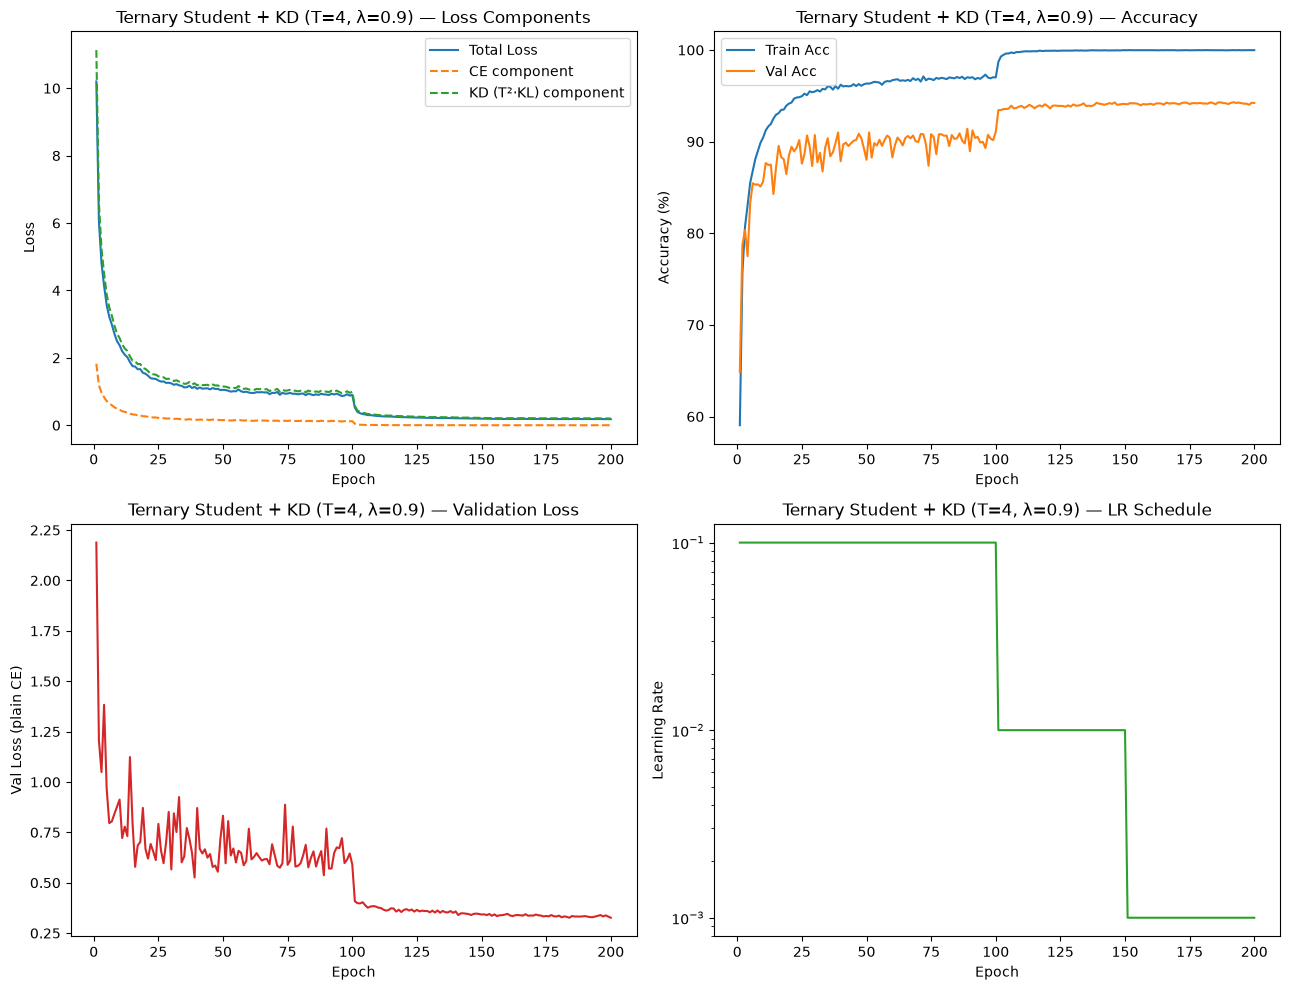

Saved: ./checkpoints/student_main_curves.png


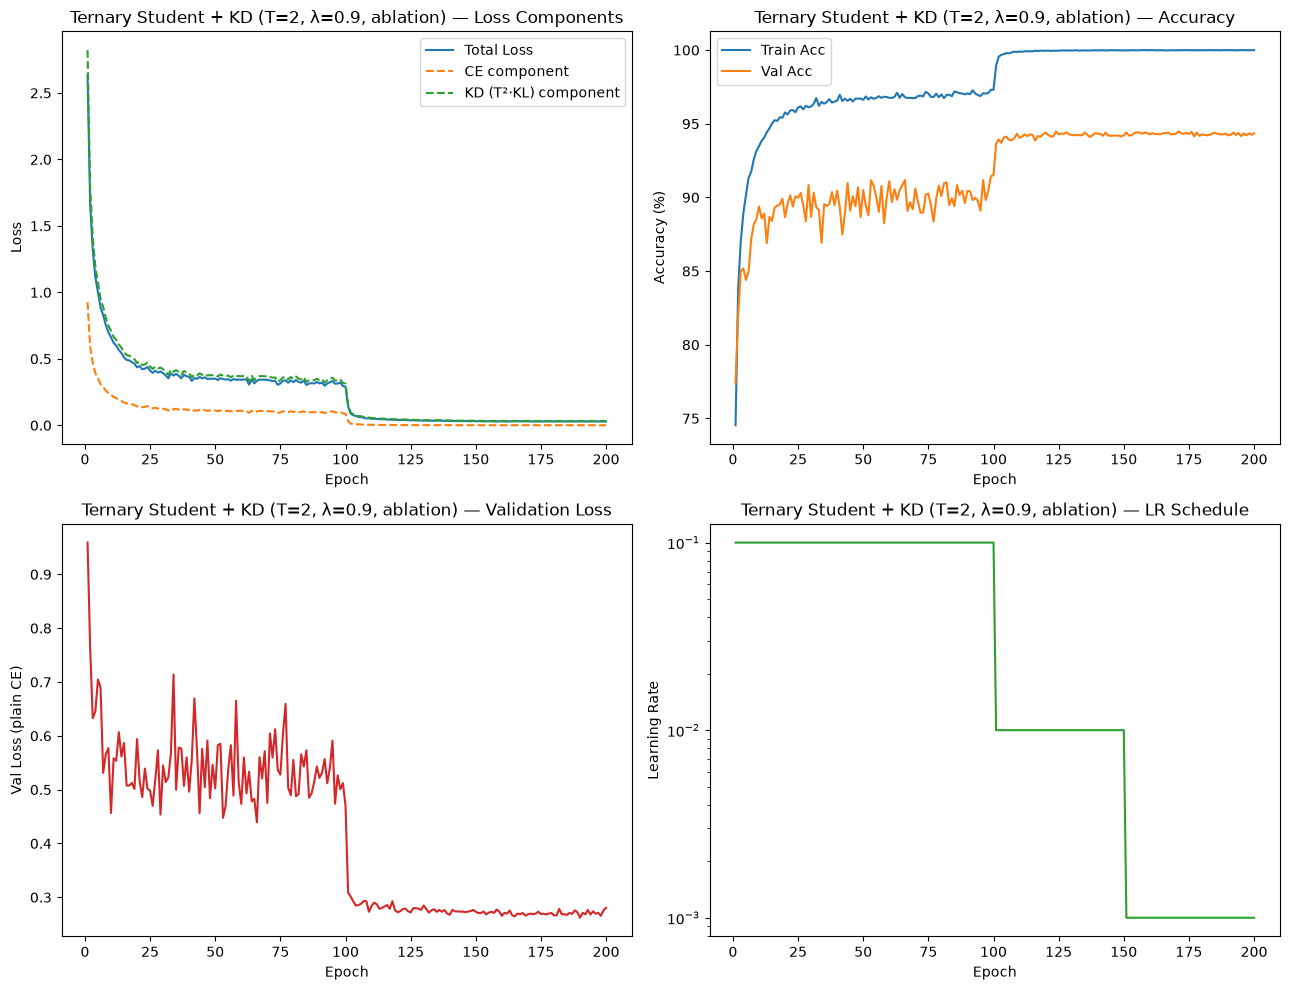

Saved: ./checkpoints/student_ablation_curves.png


In [54]:
#Cell 41 — KD training curves (main + ablation runs)
def plot_kd_curves(history, title_prefix, save_path):
    """2x2 grid: loss components, train/val accuracy, val loss, LR schedule."""
    epochs = range(1, len(history["total_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    axes[0,0].plot(epochs, history["total_loss"], label="Total Loss")
    axes[0,0].plot(epochs, history["ce_loss"], label="CE component", linestyle="--")
    axes[0,0].plot(epochs, history["kd_loss"], label="KD (T²·KL) component", linestyle="--")
    axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Loss")
    axes[0,0].set_title(f"{title_prefix} — Loss Components"); axes[0,0].legend()

    axes[0,1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[0,1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[0,1].set_xlabel("Epoch"); axes[0,1].set_ylabel("Accuracy (%)")
    axes[0,1].set_title(f"{title_prefix} — Accuracy"); axes[0,1].legend()

    axes[1,0].plot(epochs, history["val_loss"], color="tab:red")
    axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("Val Loss (plain CE)")
    axes[1,0].set_title(f"{title_prefix} — Validation Loss")

    axes[1,1].plot(epochs, history["lr"], color="tab:green")
    axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("Learning Rate")
    axes[1,1].set_yscale("log")
    axes[1,1].set_title(f"{title_prefix} — LR Schedule")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

plot_kd_curves(main_results["history"], "Ternary Student + KD (T=4, λ=0.9)",
               os.path.join(CHECKPOINT_DIR, "student_main_curves.png"))
plot_kd_curves(ablation_results["history"], "Ternary Student + KD (T=2, λ=0.9, ablation)",
               os.path.join(CHECKPOINT_DIR, "student_ablation_curves.png"))

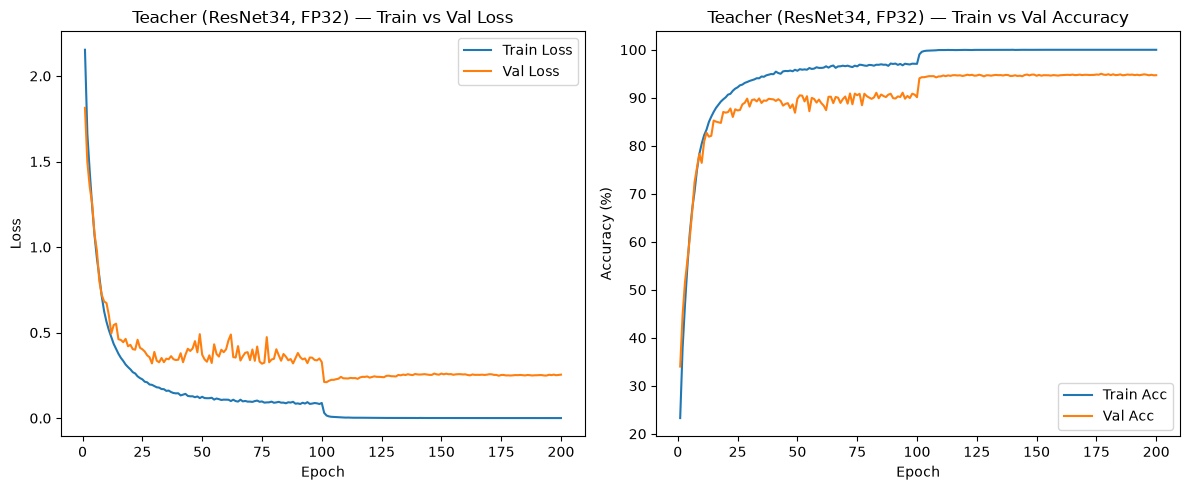

Saved: ./checkpoints/teacher_train_val_curves.png


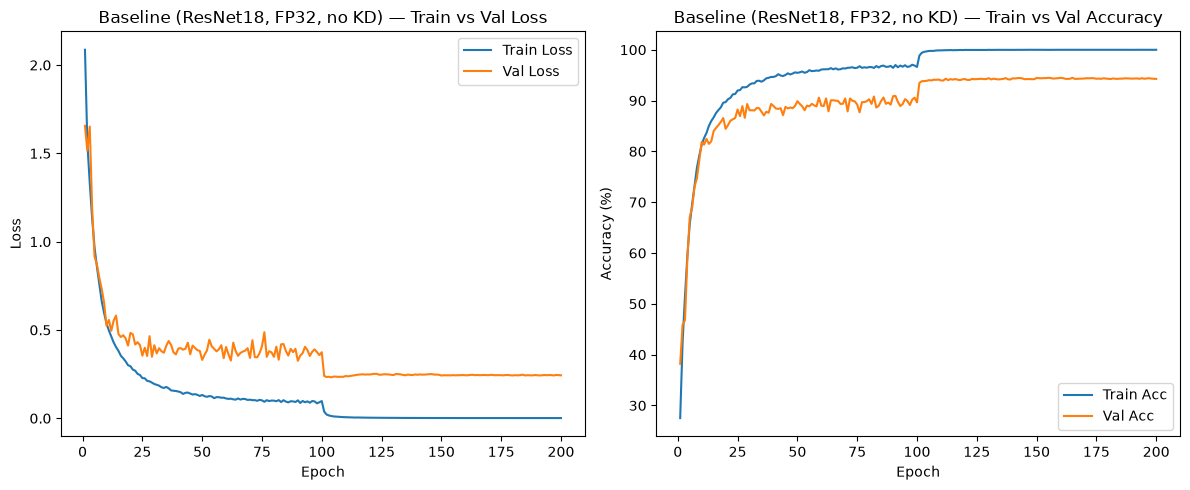

Saved: ./checkpoints/baseline_train_val_curves.png


In [56]:
#Cell 41b — Train vs. validation curves for Teacher and Baseline 
# Load both histories explicitly here, so this cell doesn't depend on Cell 42 running first
with open(os.path.join(CHECKPOINT_DIR, "teacher_history.json")) as f:
    teacher_history = json.load(f)
with open(os.path.join(CHECKPOINT_DIR, "baseline_final_results.json")) as f:
    baseline_history = json.load(f)["history"]

def plot_train_val_curves(history, title_prefix, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title_prefix} — Train vs Val Loss"); axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title(f"{title_prefix} — Train vs Val Accuracy"); axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

plot_train_val_curves(teacher_history, "Teacher (ResNet34, FP32)",
                       os.path.join(CHECKPOINT_DIR, "teacher_train_val_curves.png"))

plot_train_val_curves(baseline_history, "Baseline (ResNet18, FP32, no KD)",
                       os.path.join(CHECKPOINT_DIR, "baseline_train_val_curves.png"))

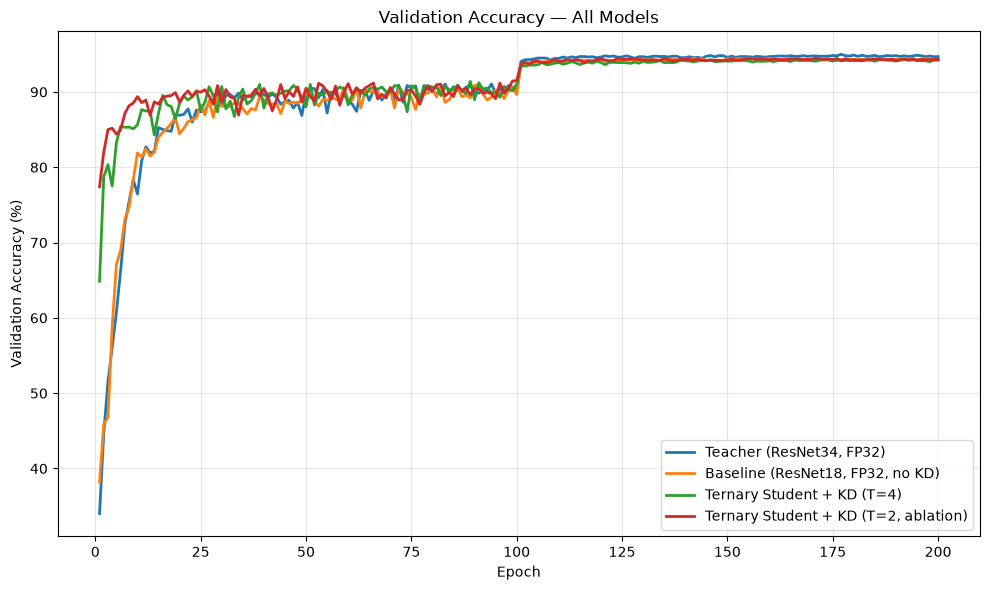

In [57]:
#Cell 42 — Cross-model validation accuracy comparison (all 4 on one plot)
# Reload teacher/baseline history for direct comparison (already saved from Tasks 1-2)
with open(os.path.join(CHECKPOINT_DIR, "teacher_history.json")) as f:
    teacher_history = json.load(f)
with open(os.path.join(CHECKPOINT_DIR, "baseline_final_results.json")) as f:
    baseline_history = json.load(f)["history"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(teacher_history["val_acc"])+1), teacher_history["val_acc"],
        label="Teacher (ResNet34, FP32)", linewidth=2)
ax.plot(range(1, len(baseline_history["val_acc"])+1), baseline_history["val_acc"],
        label="Baseline (ResNet18, FP32, no KD)", linewidth=2)
ax.plot(range(1, len(main_results["history"]["val_acc"])+1), main_results["history"]["val_acc"],
        label="Ternary Student + KD (T=4)", linewidth=2)
ax.plot(range(1, len(ablation_results["history"]["val_acc"])+1), ablation_results["history"]["val_acc"],
        label="Ternary Student + KD (T=2, ablation)", linewidth=2)

ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Validation Accuracy — All Models")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "all_models_val_acc_comparison.png"), dpi=150)
plt.show()

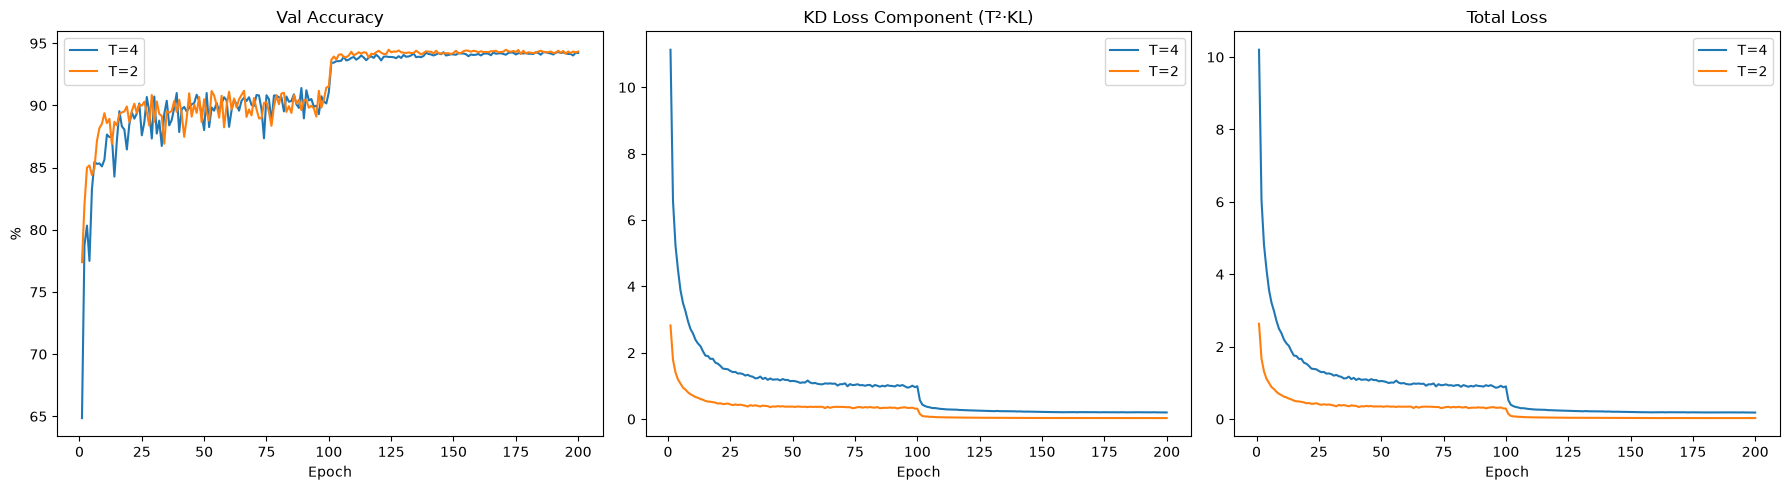

T=4 best val acc: 94.30% (epoch 192)
T=2 best val acc: 94.48% (epoch 124)
T=4 final test acc: 94.29%
T=2 final test acc: 94.28%


In [58]:
#Cell 43 — T-ablation direct comparison (T=4 vs T=2)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for results, label, color in [(main_results, "T=4", "tab:blue"), (ablation_results, "T=2", "tab:orange")]:
    h = results["history"]
    ep = range(1, len(h["val_acc"]) + 1)
    axes[0].plot(ep, h["val_acc"], label=label, color=color)
    axes[1].plot(ep, h["kd_loss"], label=label, color=color)
    axes[2].plot(ep, h["total_loss"], label=label, color=color)

axes[0].set_title("Val Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("%"); axes[0].legend()
axes[1].set_title("KD Loss Component (T²·KL)"); axes[1].set_xlabel("Epoch"); axes[1].legend()
axes[2].set_title("Total Loss"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "T_ablation_comparison.png"), dpi=150)
plt.show()

print(f"T=4 best val acc: {main_results['best_val_acc']:.2f}% (epoch {main_results['best_epoch']})")
print(f"T=2 best val acc: {ablation_results['best_val_acc']:.2f}% (epoch {ablation_results['best_epoch']})")
print(f"T=4 final test acc: {final_evaluation['student_ternary_kd_T4_lam0.9']['test_acc']:.2f}%")
print(f"T=2 final test acc: {final_evaluation['student_ternary_kd_T2_lam0.9']['test_acc']:.2f}%")

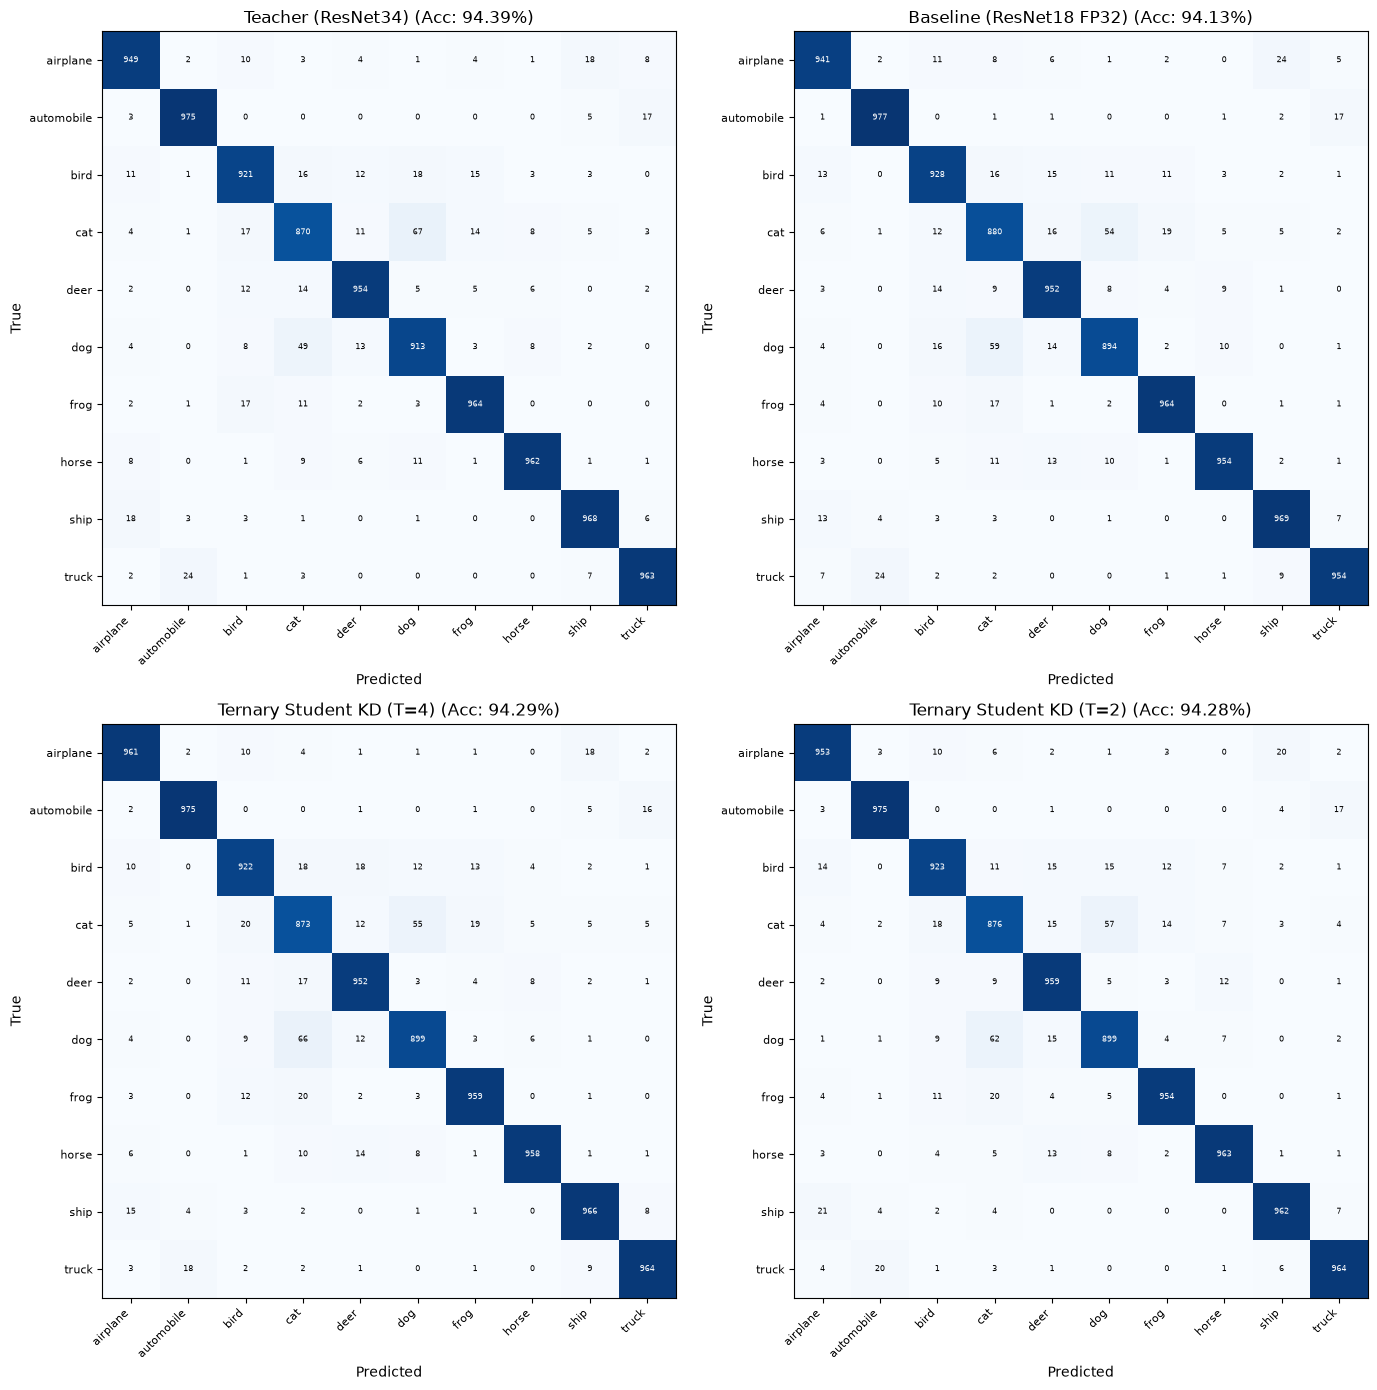

In [59]:
#Cell 44 — Confusion matrices for all 4 models (manual computation, no sklearn dependency)
CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def compute_confusion_matrix(preds, labels, num_classes=10):
    """Manual confusion matrix: cm[true][pred] += 1"""
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(labels, preds):
        cm[t][p] += 1
    return cm

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
model_keys = ["teacher_resnet34", "baseline_resnet18_fp32",
              "student_ternary_kd_T4_lam0.9", "student_ternary_kd_T2_lam0.9"]
titles = ["Teacher (ResNet34)", "Baseline (ResNet18 FP32)",
          "Ternary Student KD (T=4)", "Ternary Student KD (T=2)"]

for ax, key, title in zip(axes.flat, model_keys, titles):
    result = final_evaluation[key]
    cm = compute_confusion_matrix(result["predictions"], result["true_labels"])
    # Normalize per row (per true class) so the heatmap shows recall per class
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(CIFAR10_CLASSES, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{title} (Acc: {result['test_acc']:.2f}%)")

    for i in range(10):
        for j in range(10):
            ax.text(j, i, f"{cm[i,j]}", ha="center", va="center",
                     fontsize=6, color="white" if cm_norm[i,j] > 0.5 else "black")

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "confusion_matrices_all_models.png"), dpi=150)
plt.show()

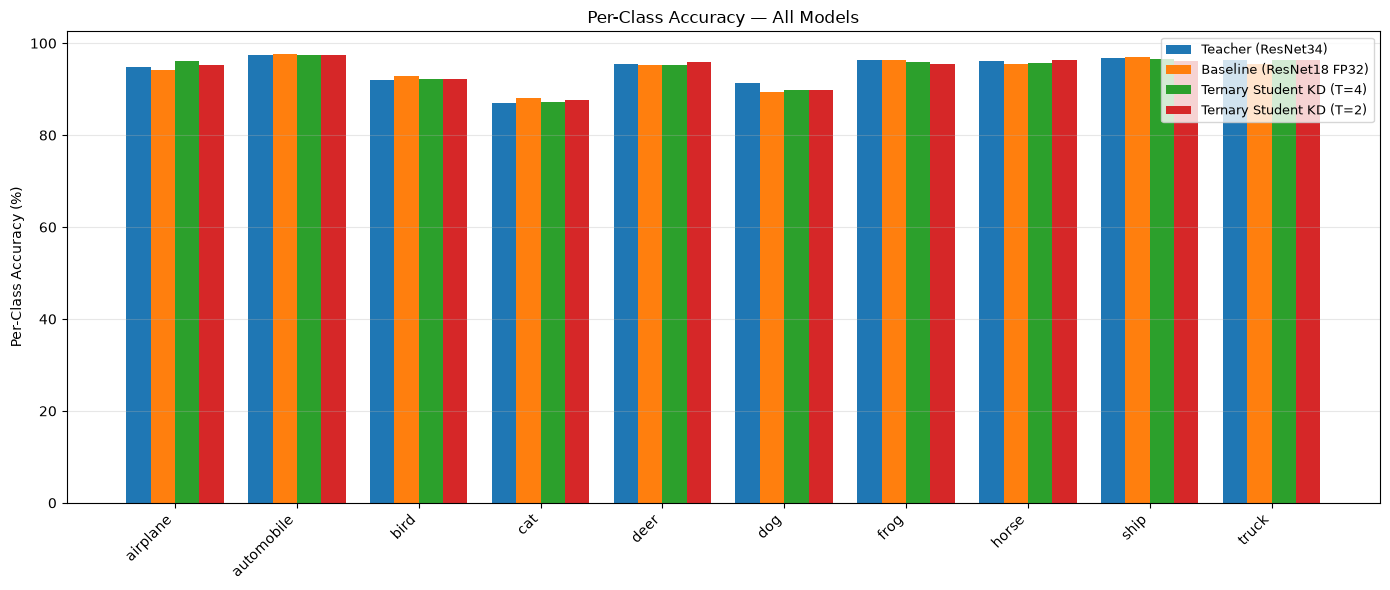

In [60]:
#Cell 45 — Per-class accuracy comparison bar chart
def per_class_accuracy(preds, labels, num_classes=10):
    cm = compute_confusion_matrix(preds, labels, num_classes)
    return cm.diagonal() / cm.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(10)
width = 0.2

for i, (key, label) in enumerate(zip(model_keys, titles)):
    acc = per_class_accuracy(final_evaluation[key]["predictions"], final_evaluation[key]["true_labels"])
    ax.bar(x + i*width, acc, width=width, label=label)

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.set_ylabel("Per-Class Accuracy (%)")
ax.set_title("Per-Class Accuracy — All Models")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "per_class_accuracy_comparison.png"), dpi=150)
plt.show()

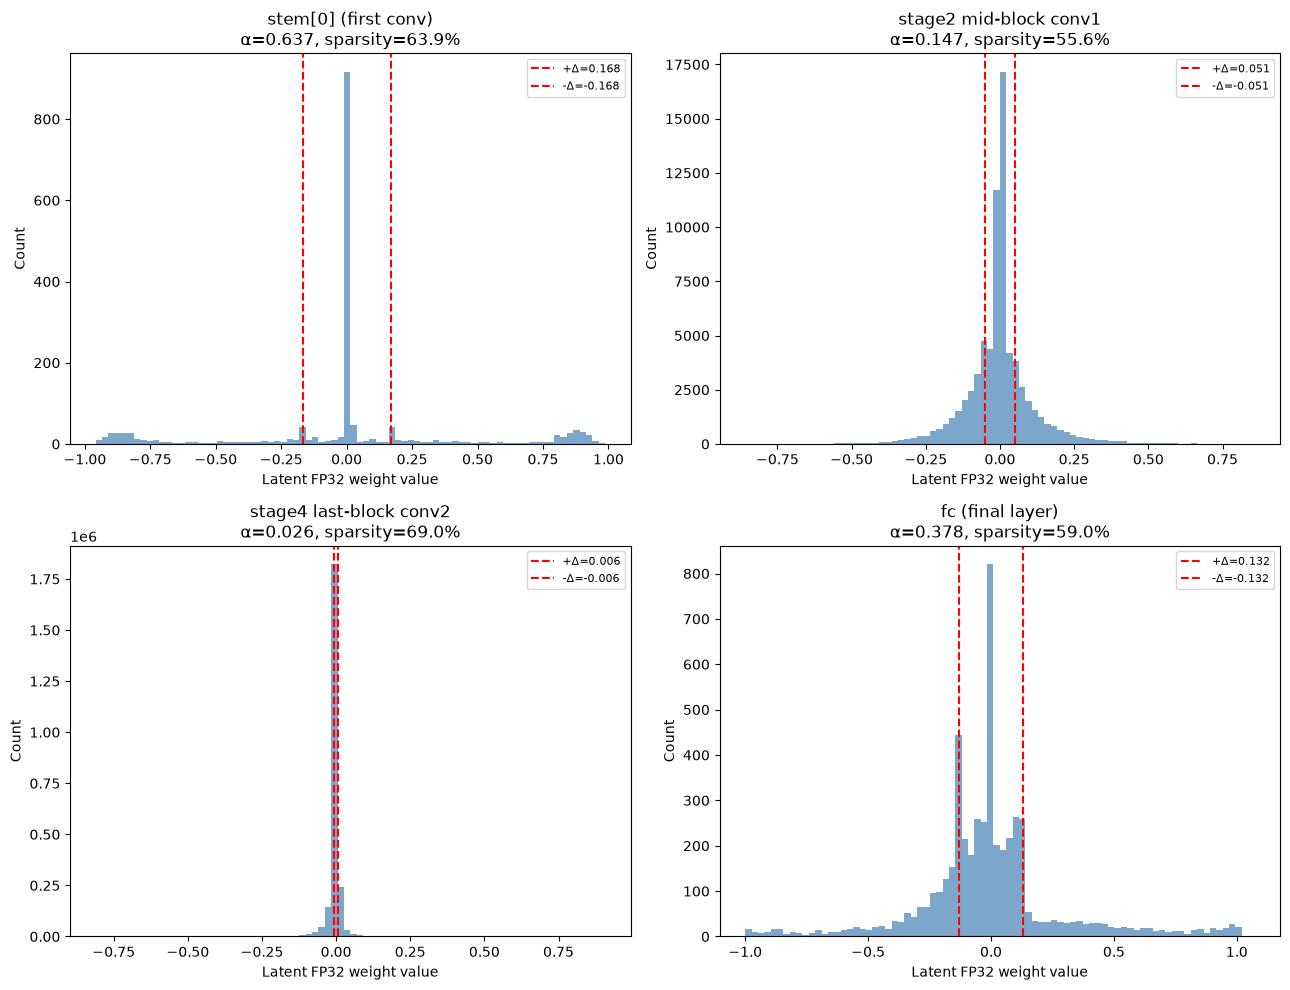

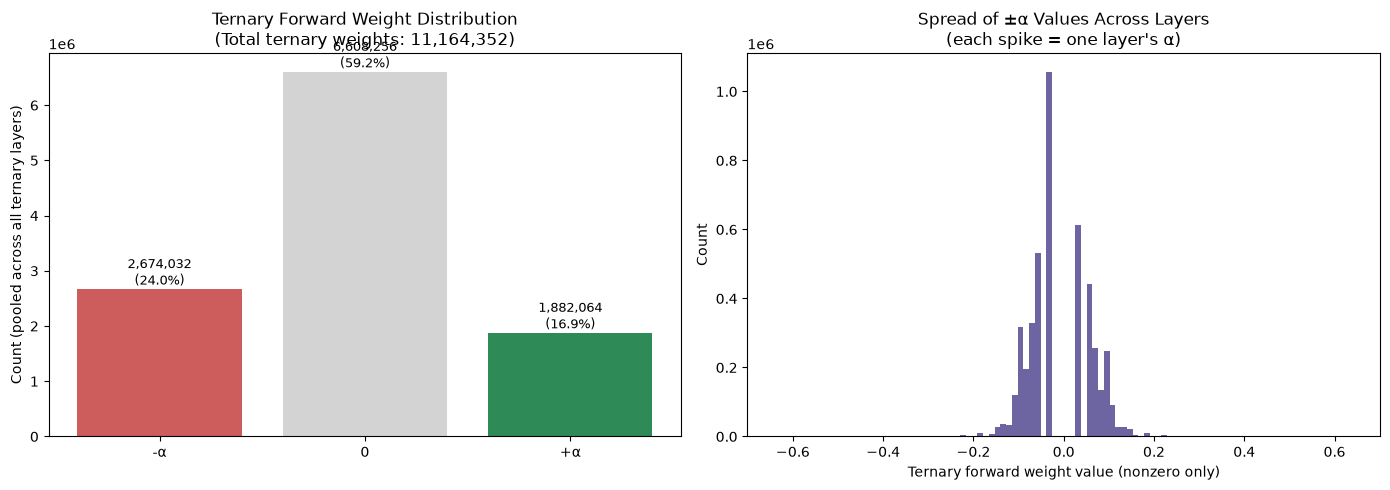

Pooled ternary forward weights — Negative: 2,674,032 (23.95%), Zero: 6,608,256 (59.19%), Positive: 1,882,064 (16.86%)


In [61]:
#Cell 46 — Latent weight histograms for representative ternary layers (first / middle / last)
# --- Part A: latent FP32 histograms (unchanged from before) ---
representative_layers = {
    "stem[0] (first conv)": student_main_eval.stem[0],
    "stage2 mid-block conv1": student_main_eval.stage2[0].conv1,
    "stage4 last-block conv2": student_main_eval.stage4[-1].conv2,
    "fc (final layer)": student_main_eval.fc,
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (name, layer) in zip(axes.flat, representative_layers.items()):
    W = layer.weight.detach().cpu().numpy().flatten()
    delta, alpha, sparsity = compute_twn_stats(layer.weight)
    ax.hist(W, bins=80, color="steelblue", alpha=0.7)
    ax.axvline(delta, color="red", linestyle="--", label=f"+Δ={delta:.3f}")
    ax.axvline(-delta, color="red", linestyle="--", label=f"-Δ={-delta:.3f}")
    ax.set_title(f"{name}\nα={alpha:.3f}, sparsity={sparsity*100:.1f}%")
    ax.set_xlabel("Latent FP32 weight value"); ax.set_ylabel("Count")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "latent_weight_histograms.png"), dpi=150)
plt.show()

# --- Part B: pooled TERNARY FORWARD weight distribution, across the WHOLE model ---
# Categorical counts of {-alpha, 0, +alpha}, pooled over every ternary layer.
# Since alpha differs per layer, we count by SIGN category (not raw value),
# which is the meaningful comparison across a model with per-layer scales.
neg_count, zero_count, pos_count = 0, 0, 0
nonzero_values = []  # for the secondary histogram showing the spread of actual alphas

for name, module in student_main_eval.named_modules():
    if isinstance(module, (TernaryConv2d, TernaryLinear)):
        W_ternary = ternarize(module.weight, module.clip_value).detach().cpu().numpy().flatten()
        neg_count += (W_ternary < 0).sum()
        zero_count += (W_ternary == 0).sum()
        pos_count += (W_ternary > 0).sum()
        nonzero_values.extend(W_ternary[W_ternary != 0].tolist())

total_ternary = neg_count + zero_count + pos_count

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: the three categories, pooled across the entire model
categories = ["-α", "0", "+α"]
counts = [neg_count, zero_count, pos_count]
colors = ["indianred", "lightgray", "seagreen"]
bars = axes[0].bar(categories, counts, color=colors)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f"{count:,}\n({100*count/total_ternary:.1f}%)",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_ylabel("Count (pooled across all ternary layers)")
axes[0].set_title(f"Ternary Forward Weight Distribution\n(Total ternary weights: {total_ternary:,})")

# Histogram of actual nonzero VALUES (shows the different alpha magnitudes per layer as separate spikes)
axes[1].hist(nonzero_values, bins=100, color="darkslateblue", alpha=0.8)
axes[1].set_xlabel("Ternary forward weight value (nonzero only)")
axes[1].set_ylabel("Count")
axes[1].set_title("Spread of ±α Values Across Layers\n(each spike = one layer's α)")

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "ternary_forward_weight_distribution.png"), dpi=150)
plt.show()

print(f"Pooled ternary forward weights — Negative: {neg_count:,} ({100*neg_count/total_ternary:.2f}%), "
      f"Zero: {zero_count:,} ({100*zero_count/total_ternary:.2f}%), "
      f"Positive: {pos_count:,} ({100*pos_count/total_ternary:.2f}%)")

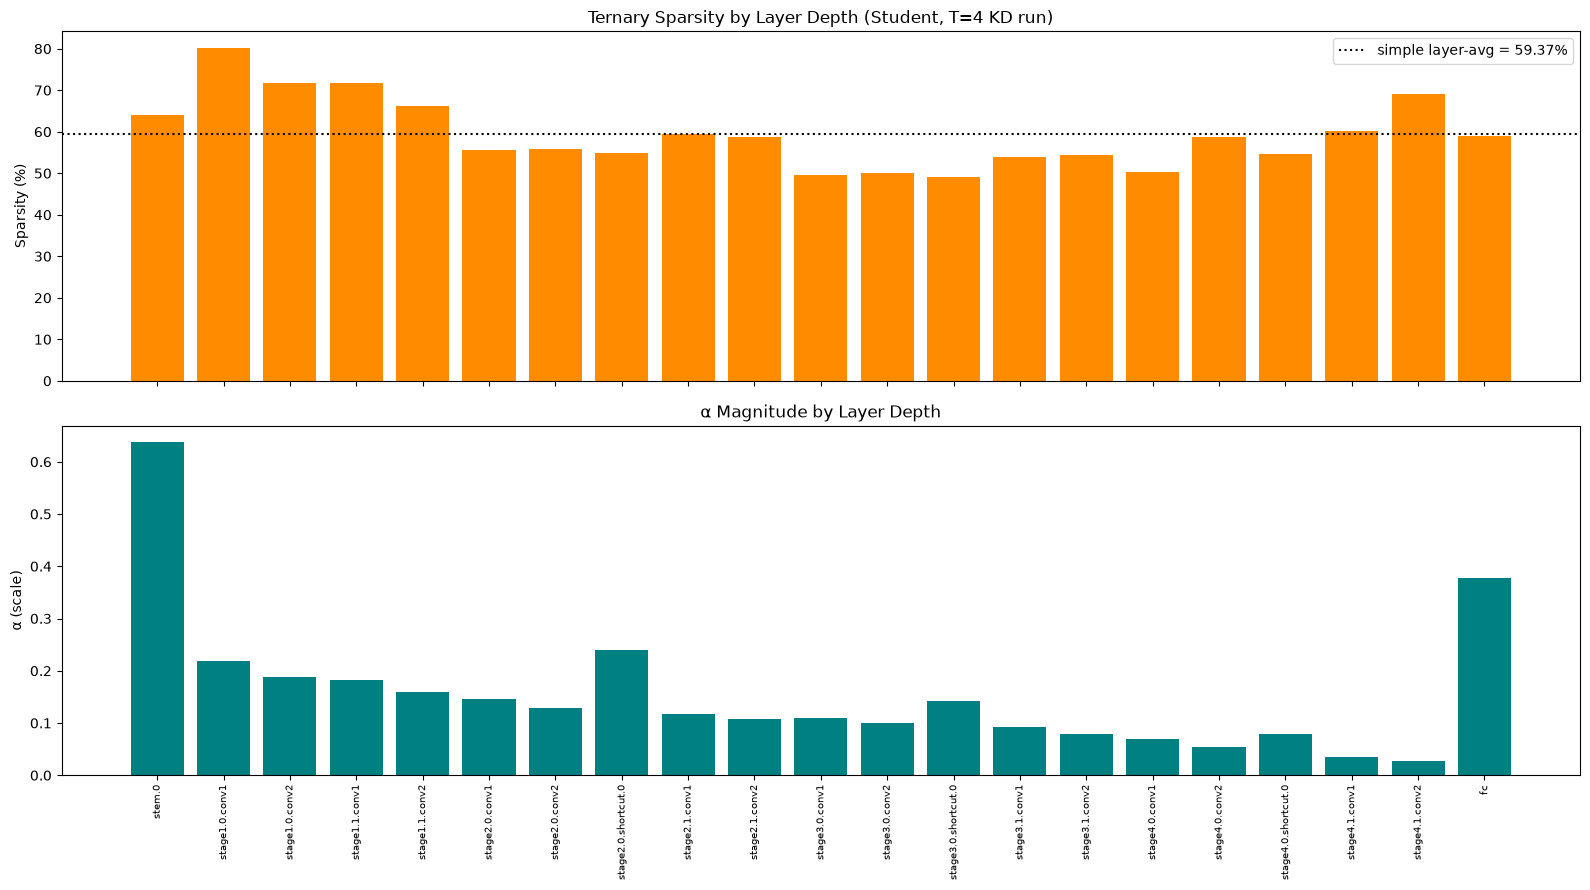

Simple average of per-layer sparsities:      59.37%  (misleading - ignores layer size)
TRUE weighted global sparsity:                59.19%  (6,608,256 zeros / 11,164,352 total ternary weights)
Saved: ./checkpoints/global_sparsity_summary.json


In [62]:
#Cell 47 (revised) — layer-wise plots (unchanged) + true weighted global sparsity
layer_names, sparsities, alphas, layer_weight_counts, layer_zero_counts = [], [], [], [], []

for name, module in student_main_eval.named_modules():
    if isinstance(module, (TernaryConv2d, TernaryLinear)):
        delta, alpha, sparsity = module.get_stats()
        n_weights = module.weight.numel()
        n_zeros = round(sparsity * n_weights)  # from get_stats()'s sparsity fraction

        layer_names.append(name)
        sparsities.append(sparsity * 100)
        alphas.append(alpha)
        layer_weight_counts.append(n_weights)
        layer_zero_counts.append(n_zeros)

# --- Layer-wise plots (unchanged) ---
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
axes[0].bar(range(len(layer_names)), sparsities, color="darkorange")
axes[0].set_ylabel("Sparsity (%)")
axes[0].set_title("Ternary Sparsity by Layer Depth (Student, T=4 KD run)")
axes[0].axhline(sum(sparsities)/len(sparsities), color="black", linestyle=":",
                label=f"simple layer-avg = {sum(sparsities)/len(sparsities):.2f}%")
axes[0].legend()

axes[1].bar(range(len(layer_names)), alphas, color="teal")
axes[1].set_ylabel("α (scale)")
axes[1].set_xticks(range(len(layer_names)))
axes[1].set_xticklabels(layer_names, rotation=90, fontsize=7)
axes[1].set_title("α Magnitude by Layer Depth")

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "layerwise_sparsity_alpha.png"), dpi=150)
plt.show()

# --- TRUE global sparsity: weighted by each layer's actual weight COUNT, not a simple average ---
# Simple average treats a 64-weight layer and a 500k-weight layer as equally important -
# this instead sums total zeros / total weights across the WHOLE model, which is what
# actually determines real storage/compute savings.
total_weights_all_layers = sum(layer_weight_counts)
total_zeros_all_layers = sum(layer_zero_counts)
true_global_sparsity = 100 * total_zeros_all_layers / total_weights_all_layers
simple_avg_sparsity = sum(sparsities) / len(sparsities)

print(f"Simple average of per-layer sparsities:      {simple_avg_sparsity:.2f}%  (misleading - ignores layer size)")
print(f"TRUE weighted global sparsity:                {true_global_sparsity:.2f}%  "
      f"({total_zeros_all_layers:,} zeros / {total_weights_all_layers:,} total ternary weights)")

sparsity_summary = {
    "simple_average_sparsity_pct": round(simple_avg_sparsity, 2),
    "true_weighted_global_sparsity_pct": round(true_global_sparsity, 2),
    "total_ternary_weights": int(total_weights_all_layers),
    "total_zero_weights": int(total_zeros_all_layers),
    "per_layer": [
        {"layer": name, "n_weights": int(n), "n_zeros": int(z), "sparsity_pct": round(s, 2), "alpha": round(a, 4)}
        for name, n, z, s, a in zip(layer_names, layer_weight_counts, layer_zero_counts, sparsities, alphas)
    ]
}
with open(os.path.join(CHECKPOINT_DIR, "global_sparsity_summary.json"), "w") as f:
    json.dump(sparsity_summary, f, indent=2)
print(f"Saved: {os.path.join(CHECKPOINT_DIR, 'global_sparsity_summary.json')}")

In [68]:
!pip install datasets --quiet --break-system-packages

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [69]:
#Cell 48 — Install/import + load 10 images per class from CIFARNet's test split
#pip install datasets --break-system-packages   (run in a terminal cell if not already installed)
from datasets import load_dataset
from collections import defaultdict

cifarnet_test = load_dataset("EleutherAI/cifarnet", split="test")

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Collect exactly 10 images per class (label 0-9), stopping early once all classes are full
per_class_images = defaultdict(list)
target_per_class = 10

for example in cifarnet_test:
    label = example["label"]
    if len(per_class_images[label]) < target_per_class:
        per_class_images[label].append(example["img"])
    if all(len(v) >= target_per_class for v in per_class_images.values()) and len(per_class_images) == 10:
        break

for cls_idx in range(10):
    print(f"{CIFAR10_CLASSES[cls_idx]}: {len(per_class_images[cls_idx])} images collected")

ModuleNotFoundError: No module named 'datasets'

In [ ]:
##Cell 49 — Preprocess (resize 64→32, same CIFAR-10 normalization) and build a tensor batch
from PIL import Image

# SAME normalization stats as training - the model expects CIFAR-10 statistics,
# not CIFARNet's own, since that's what it was trained on.
cifarnet_transform = transforms.Compose([
    transforms.Resize((32, 32)),  # 64x64 -> 32x32 to match model input size
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

all_images, all_true_labels = [], []
for cls_idx in range(10):
    for img in per_class_images[cls_idx]:
        img = img.convert("RGB")  # ensure 3-channel, some ImageNet-derived images may be grayscale
        all_images.append(cifarnet_transform(img))
        all_true_labels.append(cls_idx)

cifarnet_batch = torch.stack(all_images).to(device)
cifarnet_labels = torch.tensor(all_true_labels).to(device)
print(f"Batch shape: {cifarnet_batch.shape} (expect [100, 3, 32, 32])")

In [ ]:
#Cell 50 — Run inference with the best ternary student checkpoint#
# Reload the best ternary student (T=4 main run) fresh, exactly as done for test-set eval
cifarnet_eval_model = ResNet18Ternary(num_classes=10, clip_value=1.0).to(device)
ckpt = torch.load(os.path.join(CHECKPOINT_DIR, "student_main_T4_lam0.9_best.pth"), map_location=device)
cifarnet_eval_model.load_state_dict(ckpt["model_state_dict"])
cifarnet_eval_model.eval()

with torch.no_grad():
    logits = cifarnet_eval_model(cifarnet_batch)
    preds = logits.argmax(dim=1)

overall_acc = (preds == cifarnet_labels).float().mean().item() * 100
print(f"Overall accuracy on CIFARNet (100 images, 10/class): {overall_acc:.2f}%")

# Per-class breakdown
print("\nPer-class accuracy:")
for cls_idx in range(10):
    mask = cifarnet_labels == cls_idx
    cls_acc = (preds[mask] == cifarnet_labels[mask]).float().mean().item() * 100
    print(f"  {CIFAR10_CLASSES[cls_idx]:<12} {cls_acc:.1f}%  "
          f"({(preds[mask]==cifarnet_labels[mask]).sum().item()}/{mask.sum().item()})")

In [ ]:
#Cell 51 — Confusion matrix for this OOD test + save results
preds_np = preds.cpu().numpy()
labels_np = cifarnet_labels.cpu().numpy()

cm_cifarnet = compute_confusion_matrix(preds_np.tolist(), labels_np.tolist())

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_cifarnet, cmap="Purples")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(CIFAR10_CLASSES, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Ternary Student on CIFARNet (OOD)\nOverall Acc: {overall_acc:.1f}%")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm_cifarnet[i,j], ha="center", va="center", fontsize=8,
                 color="white" if cm_cifarnet[i,j] > cm_cifarnet.max()/2 else "black")
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "cifarnet_confusion_matrix.png"), dpi=150)
plt.show()

cifarnet_results = {
    "dataset": "EleutherAI/cifarnet (test split, 64x64 resized to 32x32)",
    "model": "student_main_T4_lam0.9_best.pth",
    "n_images_per_class": target_per_class,
    "overall_accuracy": overall_acc,
    "per_class_accuracy": {
        CIFAR10_CLASSES[i]: float((preds[cifarnet_labels==i]==i).float().mean().item()*100)
        for i in range(10)
    },
    "predictions": preds_np.tolist(),
    "true_labels": labels_np.tolist(),
}
with open(os.path.join(CHECKPOINT_DIR, "cifarnet_ood_evaluation.json"), "w") as f:
    json.dump(cifarnet_results, f, indent=2)
print(f"Saved: {os.path.join(CHECKPOINT_DIR, 'cifarnet_ood_evaluation.json')}")